In [ ]:
import json
import os
import random
import shutil

import numpy as np
import pandas as pd
from scipy.signal import argrelextrema

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv1D, SpatialDropout1D, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, confusion_matrix, classification_report

# Skip entries whose raw ATR barrier exceeds the side-specific cap. Caps are fractions of entry price;
M2_MAX_TARGET_PCT_LONG      = None    # side-specific rule: no maximum distance on longs
M2_MAX_TARGET_PCT_SHORT     = 0.007   # side-specific rule: 0.70% ceiling on shorts

# M1 (Pivot Gate)

### Load data

In [ ]:
start_time = "2022-02-01 00:00:00"
end_time   = "2026-09-10 00:00:00"

FILEPATH = 'libs/BTCUSDT-M5.csv'

df = pd.read_csv(FILEPATH, index_col=0, parse_dates=True)
df.index = pd.to_datetime(df.index, unit='s', errors='coerce')

df = df[(df.index >= start_time) & (df.index <= end_time)]

df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 484270 entries, 2022-02-01 00:00:00+00:00 to 2026-09-09 23:55:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Volume  484270 non-null  int64  
 1   Open    484270 non-null  float64
 2   High    484270 non-null  float64
 3   Low     484270 non-null  float64
 4   Close   484270 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 22.2 MB


## M1 - Extended Kalman Filter

Note: Before any features are built, the raw 5-minute candles pass through an adaptive Kalman filter that I've kept proprietary, so its code isn't included in this repo. Its purpose is denoising: it strips microstructure noise from the OHLC series and returns a cleaner price path along with a few derived signals that feed the models. The figure below illustrates the effect (raw vs. filtered price) so the behaviour is visible without the internals. Everything downstream runs on the filter's precomputed outputs.

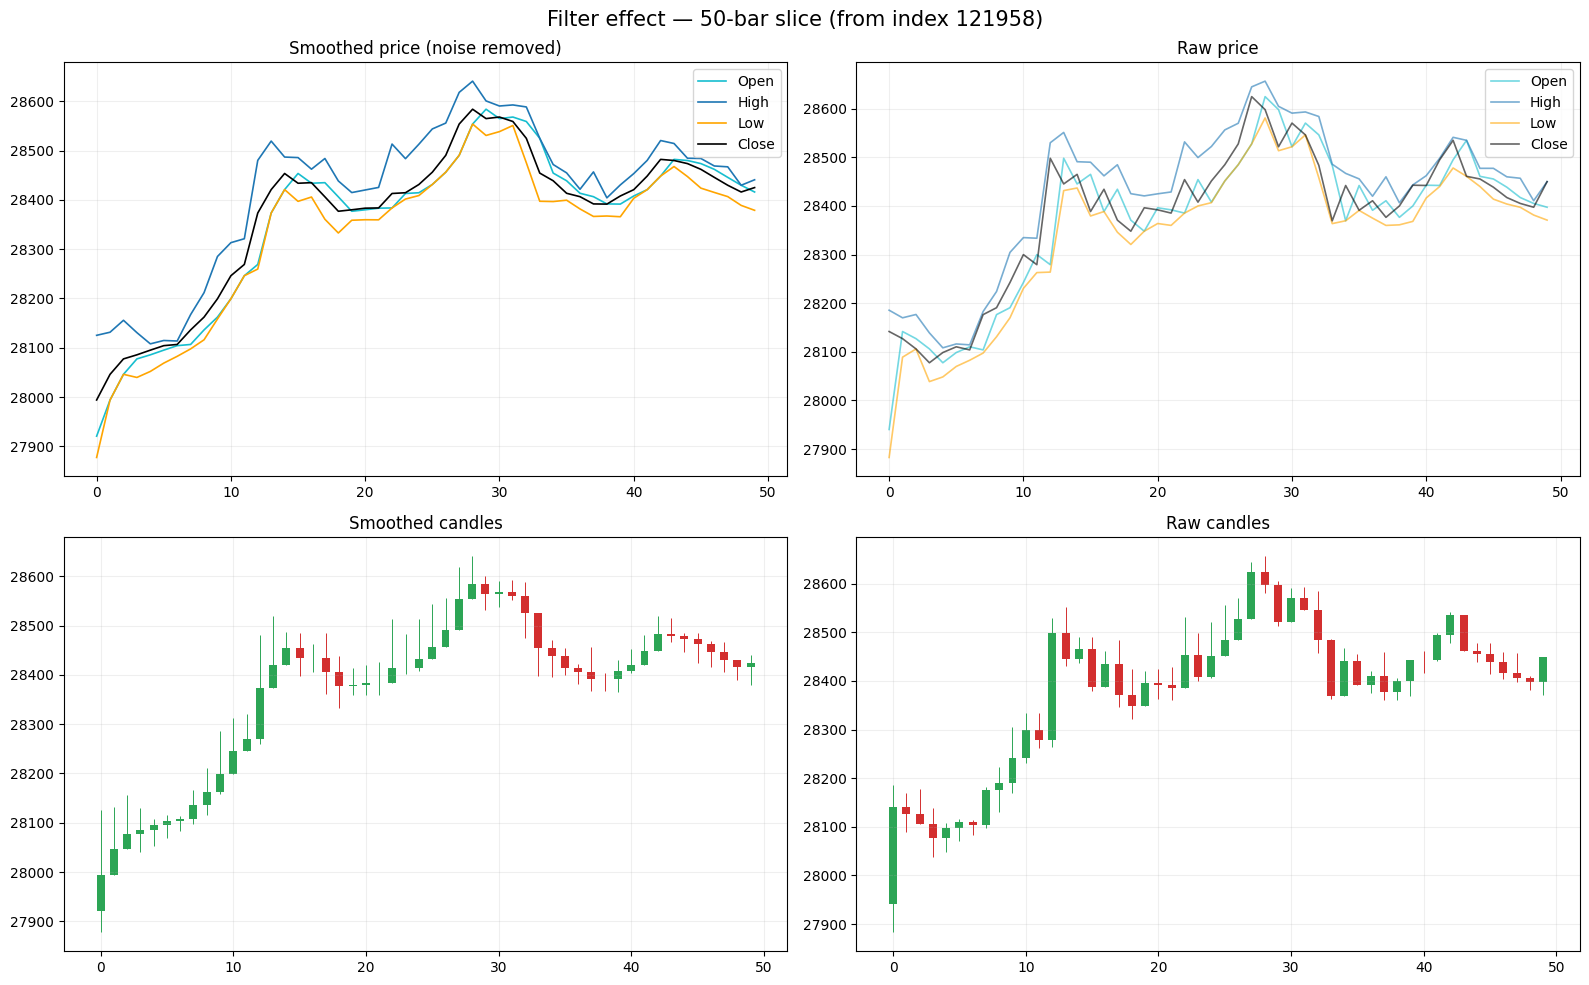

121958

In [20]:
plot_filter_effect(df)

In [ ]:
df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'vol_estimate', 'q_multiplier',
         'norm_innovation', 'signed_observation_surprise',
         'level_uncertainty_norm', 'velocity_uncertainty_norm', 'filtered_velocity', 'target_price', 'target_velocity',
         'mode_prob_responsive', 'vol_process', 'dir_ratio', 'robust_scale',
         'open', 'high', 'low', 'close']] # Where Open, High, Low, Close are the filtered values and open, high, low, close are the raw values.
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 484270 entries, 2022-02-01 00:00:00+00:00 to 2026-09-09 23:55:00+00:00
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Open                         484270 non-null  float64
 1   High                         484270 non-null  float64
 2   Low                          484270 non-null  float64
 3   Close                        484270 non-null  float64
 4   Volume                       484270 non-null  int64  
 5   vol_estimate                 484270 non-null  float64
 6   q_multiplier                 484270 non-null  float64
 7   norm_innovation              484270 non-null  float64
 8   signed_observation_surprise  484270 non-null  float64
 9   level_uncertainty_norm       484270 non-null  float64
 10  velocity_uncertainty_norm    484270 non-null  float64
 11  filtered_velocity            484270 non-null  float64
 12  target_price

## M1 - Class Y

In [22]:
order = 90
BAR_INTERVAL = pd.Timedelta(ekf.bar_interval)
candle_segments = df.index.to_series().diff().ne(BAR_INTERVAL).cumsum()
peaks_idx, troughs_idx = [], []
for positions in df.groupby(candle_segments, sort=False).indices.values():
    part = df.iloc[positions]
    for column, comparator, destination in [
        ('High', np.greater, peaks_idx), ('Low', np.less, troughs_idx)
    ]:
        local = argrelextrema(part[column].to_numpy(), comparator, order=order)[0]
        local = local[(local >= order) & (local + order < len(part))]
        destination.extend(positions[local])
peaks_idx = np.asarray(peaks_idx, dtype=int)
troughs_idx = np.asarray(troughs_idx, dtype=int)
df['target'] = 0
df.loc[df.index[peaks_idx], 'target'] = 1
df.loc[df.index[troughs_idx], 'target'] = 1

print(f"Total Data Points: {len(df)}")
print(f"Total Pivots: {df['target'].sum()}")
print(f"Percentage of Target candles: {df['target'].mean() * 100:.2f}%")

Total Data Points: 484270
Total Pivots: 3760
Percentage of Target candles: 0.78%


### Pivot label tolerance

In [23]:
# Allow a one-candle tolerance around each pivot.
M1_LABEL_HORIZON = order + 1
df['target'] = 0
df.loc[df.index[peaks_idx], 'target'] = 1
df.loc[df.index[troughs_idx], 'target'] = 1
df['target'] = df['target'].groupby(candle_segments).transform(
    lambda s: s.rolling(window=3, center=True, min_periods=1).max())
times = df.index.to_series()
past = times.groupby(candle_segments).shift(M1_LABEL_HORIZON)
future = times.groupby(candle_segments).shift(-M1_LABEL_HORIZON)
df['_m1_label_end'] = future
df.loc[past.isna() | future.isna(), 'target'] = np.nan

print(f"Total Data Points: {len(df)}")
print(f"Total Pivots: {df['target'].sum():.0f}")
print(f"Percentage of Target candles: {df['target'].mean() * 100:.2f}%")

Total Data Points: 484270
Total Pivots: 11277
Percentage of Target candles: 2.33%


### Inspect labels

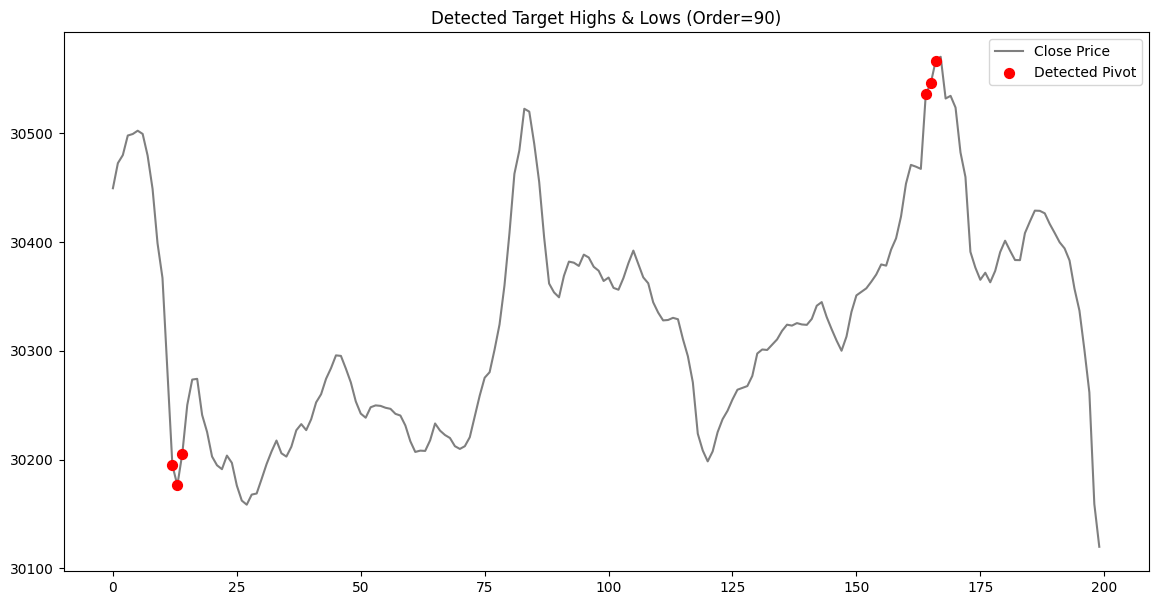

In [24]:
slice_len = 200
start_idx = np.random.randint(0, len(df) - slice_len)
subset = df.iloc[start_idx:start_idx + slice_len].reset_index(drop=True)

plt.figure(figsize=(14, 7))
plt.plot(subset.index, subset['Close'], color='black', alpha=0.5, label='Close Price')
pivots = subset[subset['target'] == 1]
plt.scatter(pivots.index, pivots['Close'], color='red', s=50, label='Detected Pivot', zorder=5)
plt.title(f'Detected Target Highs & Lows (Order={order})')
plt.legend()
plt.show()

In [25]:
df.rename(columns={'target': 'target_pivot'}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 484270 entries, 2022-02-01 00:00:00+00:00 to 2026-09-09 23:55:00+00:00
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype              
---  ------                       --------------   -----              
 0   Open                         484270 non-null  float64            
 1   High                         484270 non-null  float64            
 2   Low                          484270 non-null  float64            
 3   Close                        484270 non-null  float64            
 4   Volume                       484270 non-null  int64              
 5   vol_estimate                 484270 non-null  float64            
 6   q_multiplier                 484270 non-null  float64            
 7   norm_innovation              484270 non-null  float64            
 8   signed_observation_surprise  484270 non-null  float64            
 9   level_uncertainty_norm       484270 non-null  float64    

## M1 - Feature engineering

In [26]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = (-delta.clip(upper=0)).rolling(period).mean()
    result = 100 * gain / (gain + loss)
    return result.mask((gain + loss).eq(0), 50.0)

def true_range(data):
    prev_close = data['Close'].shift(1)
    return pd.concat([data['High'] - data['Low'],
                      (data['High'] - prev_close).abs(),
                      (data['Low'] - prev_close).abs()], axis=1).max(axis=1)

def _m1_segment_features(data):
    data = data.copy()
    c, o, h, l, v = (data[k] for k in ['Close', 'Open', 'High', 'Low', 'Volume'])
    floor = (c.abs() * 1e-8).clip(lower=1e-12)
    log_c = np.log(c)
    log_ret = log_c.diff()
    atr14 = true_range(data).rolling(14).mean()
    atr_safe = atr14.clip(lower=floor)
    dc_high, dc_low = h.rolling(20).max(), l.rolling(20).min()
    dc_range = dc_high - dc_low
    candle_range = h - l
    candle_safe = candle_range.clip(lower=floor)
    bb_mid, bb_std = c.rolling(20).mean(), c.rolling(20).std()

    data['feat_bb_width'] = 4 * bb_std / bb_mid
    data['feat_atr_norm'] = atr14 / c
    data['feat_dc_width'] = dc_range / c
    data['feat_dc_position20'] = ((c - dc_low) / dc_range.clip(lower=floor)).where(
        dc_range > floor, 0.5).clip(0, 1)
    data['feat_dist_high_atr20'] = (dc_high - c) / atr_safe
    data['feat_dist_low_atr20'] = (c - dc_low) / atr_safe
    data['feat_rsi'] = calculate_rsi(c)
    data['feat_rsi_roc'] = data['feat_rsi'].diff(3)
    macd = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    data['feat_macd_hist'] = (macd - macd.ewm(span=9, adjust=False).mean()) / atr_safe
    data['feat_roc_3'] = c.pct_change(3, fill_method=None)
    data['feat_roc_12'] = c.pct_change(12, fill_method=None)
    for horizon in [6, 24, 60]:
        data[f'feat_log_ret_{horizon}'] = log_c.diff(horizon)
    data['feat_hist_vol'] = log_ret.rolling(96).std()
    data['feat_ema_spread'] = (c.ewm(span=7, adjust=False).mean()
                               - c.ewm(span=25, adjust=False).mean()) / c
    data['feat_body_dominance'] = ((c - o).abs() / candle_safe).clip(0, 1)
    data['feat_signed_body_ratio'] = ((c - o) / candle_safe).clip(-1, 1)
    data['feat_upper_wick_ratio'] = ((h - data[['Open', 'Close']].max(axis=1))
                                     .clip(lower=0) / candle_safe).clip(0, 1)
    data['feat_lower_wick_ratio'] = ((data[['Open', 'Close']].min(axis=1) - l)
                                     .clip(lower=0) / candle_safe).clip(0, 1)
    data['feat_close_location'] = ((c - l) / candle_safe).where(
        candle_range > floor, 0.5).clip(0, 1)
    # The most recent occurrence wins when several candles share the extreme.
    data['feat_bars_since_high20'] = h.rolling(20).apply(lambda x: np.argmax(x[::-1]), raw=True)
    data['feat_bars_since_low20'] = l.rolling(20).apply(lambda x: np.argmin(x[::-1]), raw=True)

    evol = data['vol_estimate'].clip(lower=1e-10)
    raw_log_c = np.log(data['close'])
    data['feat_raw_filtered_gap_norm'] = (raw_log_c - log_c) / evol
    data['feat_raw_filtered_ret_diff'] = raw_log_c.diff() - log_ret
    ratio_floor = (0.01 * atr14).clip(lower=floor)
    data['feat_raw_filtered_range_ratio'] = (data['high'] - data['low']).clip(lower=0) / candle_range.clip(lower=ratio_floor)

    log_v = np.log1p(v.clip(lower=0))
    vol_ma = v.rolling(20).mean()
    data['feat_rvol'] = (v / vol_ma).mask(vol_ma.eq(0), 0.0)
    data['feat_vroc'] = log_v.diff(3)
    data['feat_vol_std'] = (v.rolling(20).std() / vol_ma).mask(vol_ma.eq(0), 0.0)
    vol_change = log_v.diff()
    corr = log_ret.rolling(12).corr(vol_change)
    constant = log_ret.rolling(12).std().eq(0) | vol_change.rolling(12).std().eq(0)
    data['feat_vol_price_corr'] = corr.mask(constant, 0.0).clip(-1, 1)

    vel = data['filtered_velocity']
    innov = log_c - (log_c.shift(1) + vel.shift(1))
    data['feat_innov_norm'] = innov / evol
    data['feat_innov_ema'] = data['feat_innov_norm'].ewm(span=20, adjust=False).mean()
    lag_innov = innov.shift(1)
    corr = innov.rolling(20).corr(lag_innov)
    constant = innov.rolling(20).std().eq(0) | lag_innov.rolling(20).std().eq(0)
    data['feat_innov_autocorr'] = corr.mask(constant, 0.0).clip(-1, 1)
    data['feat_innov_mag'] = data['norm_innovation'].ewm(span=20, adjust=False).mean()
    data['feat_signed_observation_surprise'] = data['signed_observation_surprise'].clip(-16, 16)
    data['feat_level_uncertainty'] = np.log1p(data['level_uncertainty_norm'])
    data['feat_velocity_uncertainty'] = np.log1p(data['velocity_uncertainty_norm'])
    data['feat_velocity_norm'] = vel / evol
    data['feat_accel_norm'] = vel.diff() / evol
    data['feat_velocity_change6'] = vel.diff(6) / evol
    pk = 1 / (2 * np.sqrt(np.log(2)))
    raw_pv = (np.log(h) - np.log(l)) * pk
    data['feat_vol_ratio'] = (raw_pv.ewm(span=ekf.vol_fast_span, adjust=False).mean()
                              / raw_pv.ewm(span=ekf.vol_slow_span, adjust=False).mean().clip(lower=1e-10))
    data['feat_vol_change'] = evol.diff() / evol
    data['feat_dir_consistency'] = np.sign(innov).rolling(10).mean()
    data['feat_ekf_log_ret'] = log_ret
    data['feat_mode_prob_responsive'] = data['mode_prob_responsive']
    data['feat_mode_prob_responsive_change'] = data['mode_prob_responsive'].diff()
    data['feat_vol_process'] = np.log(data['vol_process'].clip(lower=1e-10) / evol)
    data['feat_dir_ratio'] = data['dir_ratio']
    # Keep absolute volatility context alongside its rolling-normalized version.
    data['feat_vol_level'] = np.log1p(10000 * evol)
    data['feat_atr_level'] = np.log1p(10000 * atr14 / c)
    return data

def engineer_m1_features(frame):
    # Shared by M1 training, its prediction path, and M2's price inputs.
    data = frame.drop(columns=[c for c in frame if c.startswith('feat_')]).copy()
    segments = data.index.to_series().diff().ne(pd.Timedelta(ekf.bar_interval)).cumsum()
    parts = [_m1_segment_features(part) for _, part in data.groupby(segments, sort=False)]
    result = pd.concat(parts).sort_index() if parts else data
    return result.replace([np.inf, -np.inf], np.nan)

df = engineer_m1_features(df)
feature_list = [c for c in df if c.startswith('feat_')]
print(f"Total Features: {len(feature_list)}")
print(feature_list)

Total Features: 50
['feat_bb_width', 'feat_atr_norm', 'feat_dc_width', 'feat_dc_position20', 'feat_dist_high_atr20', 'feat_dist_low_atr20', 'feat_rsi', 'feat_rsi_roc', 'feat_macd_hist', 'feat_roc_3', 'feat_roc_12', 'feat_log_ret_6', 'feat_log_ret_24', 'feat_log_ret_60', 'feat_hist_vol', 'feat_ema_spread', 'feat_body_dominance', 'feat_signed_body_ratio', 'feat_upper_wick_ratio', 'feat_lower_wick_ratio', 'feat_close_location', 'feat_bars_since_high20', 'feat_bars_since_low20', 'feat_raw_filtered_gap_norm', 'feat_raw_filtered_ret_diff', 'feat_raw_filtered_range_ratio', 'feat_rvol', 'feat_vroc', 'feat_vol_std', 'feat_vol_price_corr', 'feat_innov_norm', 'feat_innov_ema', 'feat_innov_autocorr', 'feat_innov_mag', 'feat_signed_observation_surprise', 'feat_level_uncertainty', 'feat_velocity_uncertainty', 'feat_velocity_norm', 'feat_accel_norm', 'feat_velocity_change6', 'feat_vol_ratio', 'feat_vol_change', 'feat_dir_consistency', 'feat_ekf_log_ret', 'feat_mode_prob_responsive', 'feat_mode_prob_r

## M1 - Scaling and sequences

In [ ]:
start_time = "2022-02-01 00:00:00"
end_time   = "2026-09-10 00:00:00"
# Apply the date restriction after scaling so both M1 paths use identical history.

In [28]:
SEQ_LEN       = 60
LABEL_HORIZON = max(order + 1, 120)
EMBARGO       = 75
CHUNK_DAYS    = None  # one chronological allocation, without repeated fits
TEST_DAYS     = 400

# Earlier M1 train/validation, then later M2 train/validation, then final test.
PCT_IN_CHUNK = {
    'm1_train': 30 / 100,
    'm1_val':   5 / 100,
    'm2_train': 40 / 100,
    'm2_val':   25 / 100,
}

feature_cols = [c for c in df.columns if 'feat_' in c]
target_col = 'target_pivot'

ROLLING_SPAN = 500
Z_CLIP = 8.0

# bounded features get a fixed affine map to ~[-0.5, 0.5]; the rest a causal EWM z-score
M1_THRESHOLD = 0.85
M1_SIGNAL_GAP = 3

M1_AFFINE_FEATURES = {
    'feat_bars_since_high20': (1.0 / 19, -0.5),
    'feat_bars_since_low20':  (1.0 / 19, -0.5),
    'feat_vol_level': (0.2, 0.0),
    'feat_atr_level': (0.2, 0.0),
    'feat_signed_observation_surprise': (0.25, 0.0),
    'feat_level_uncertainty': (0.25, 0.0),
    'feat_velocity_uncertainty': (0.25, 0.0),
    'feat_dc_position20':           (1.0, -0.5),
    'feat_signed_body_ratio':       (0.5,  0.0),
    'feat_upper_wick_ratio':        (1.0, -0.5),
    'feat_lower_wick_ratio':        (1.0, -0.5),
    'feat_close_location':          (1.0, -0.5),
    'feat_rsi':             (0.01, -0.5),
    'feat_body_dominance':  (1.0, -0.5),
    'feat_vol_price_corr':  (1.0,  0.0),
    'feat_innov_autocorr':  (1.0,  0.0),
    'feat_dir_consistency': (1.0,  0.0),
    'feat_mode_prob_responsive':        (1.0, 0.0),
    'feat_mode_prob_responsive_change': (1.0, 0.0),
    'feat_dir_ratio':                   (1.0, 0.0),
}


def scale_model_features(frame, columns, affine, span=500, z_clip=8.0):
    data = frame.copy()
    segments = data.index.to_series().diff().ne(pd.Timedelta(ekf.bar_interval)).cumsum()
    for col in columns:
        if col in affine:
            scale, offset = affine[col]
            data[col] = data[col] * scale + offset
        else:
            grouped = data[col].groupby(segments, sort=False)
            mean = grouped.transform(lambda x: x.ewm(span=span, min_periods=60).mean())
            std = grouped.transform(lambda x: x.ewm(span=span, min_periods=60).std()).clip(lower=1e-12)
            data[col] = ((data[col] - mean) / std).clip(-z_clip, z_clip)
    return data.replace([np.inf, -np.inf], np.nan)

def valid_window_ends(frame, columns, length):
    finite = np.isfinite(frame[columns].to_numpy(dtype=np.float32)).all(axis=1)
    ready = pd.Series(finite).rolling(length, min_periods=length).sum().eq(length).to_numpy()
    elapsed = frame.index.to_series() - frame.index.to_series().shift(length - 1)
    ready &= elapsed.eq((length - 1) * pd.Timedelta(ekf.bar_interval)).to_numpy()
    return np.flatnonzero(ready)

df = scale_model_features(df, feature_cols, M1_AFFINE_FEATURES, ROLLING_SPAN, Z_CLIP)
df = df.loc[(df.index >= start_time) & (df.index <= end_time)].copy()
df.dropna(subset=feature_cols, inplace=True)

idx_all = df.index
X_all = df[feature_cols].to_numpy(dtype=np.float32)
y_all = df[target_col].values
N = len(df)

# The last TEST_DAYS are held out entirely; the earlier region has ordered stage roles.
test_start = idx_all.max() - pd.Timedelta(days=TEST_DAYS)
test_positions = np.where(idx_all >= test_start)[0]
rolling_idx = idx_all[idx_all < test_start]
rolling_start, rolling_end = rolling_idx.min(), rolling_idx.max()

chunk_bounds = [(rolling_start, test_start)]

print(f"Total rows after normalization: {N}")
print(f"Rolling region: {rolling_start}  -->  {rolling_end}")
print(f"Final TEST:     {idx_all[test_positions[0]]}  -->  {idx_all[test_positions[-1]]}  ({len(test_positions)} rows)")
print("Split order: M1-TRAIN -> M1-VAL -> M2-TRAIN -> M2-VAL -> TEST")

def segment_chunk(chunk_start, chunk_end, first_chunk, last_chunk):
    pos = np.where((idx_all >= chunk_start) & (idx_all < chunk_end))[0]
    if len(pos) == 0:
        return None
    cs, ce = pos[0], pos[-1] + 1
    L = ce - cs
    b1 = cs + int(L * PCT_IN_CHUNK['m1_train'])
    b2 = cs + int(L * (PCT_IN_CHUNK['m1_train'] + PCT_IN_CHUNK['m1_val']))
    b3 = cs + int(L * (PCT_IN_CHUNK['m1_train'] + PCT_IN_CHUNK['m1_val'] + PCT_IN_CHUNK['m2_train']))
    raw = {
        'm1_train': (cs, b1),
        'm1_val':   (b1, b2),
        'm2_train': (b2, b3),
        'm2_val':   (b3, ce),
    }
    keys = ['m1_train', 'm1_val', 'm2_train', 'm2_val']
    segs = {}
    for i, k in enumerate(keys):
        s, e = raw[k]
        if i < len(keys) - 1:
            e = max(s, e - LABEL_HORIZON)
        if i > 0:
            s = min(e, s + EMBARGO)
        segs[k] = (s, e)
    # Protect the last validation tail, including the boundary before final test.
    s, e = segs['m2_val']
    segs['m2_val'] = (s, max(s, e - LABEL_HORIZON))
    if not first_chunk:
        s, e = segs['m1_train']
        segs['m1_train'] = (min(e, s + EMBARGO), e)
    return segs

seg_positions = {k: [] for k in ['m1_train', 'm1_val', 'm2_train', 'm2_val']}
for ci, (cs_ts, ce_ts) in enumerate(chunk_bounds):
    segs = segment_chunk(cs_ts, ce_ts, ci == 0, ci == len(chunk_bounds) - 1)
    if segs is None:
        continue
    for k, (s, e) in segs.items():
        if e > s:
            seg_positions[k].append((s, e))

# Window CONVENTION: the lookback INCLUDES the bar being labeled.
# X = bars [i - SEQ_LEN + 1, i] (inclusive), y = target_pivot at bar i.
# Bar i's features are all causal (trailing rollings/EWMs + forward-only IMM filter
# state), so seeing it is not lookahead -- it is the bar whose High/Low DEFINES the
# argrelextrema pivot, and withholding it turned detection into a 1-bar forecast.
# The inference cell must use the identical alignment.
eligible_window_ends = set(valid_window_ends(df, feature_cols, SEQ_LEN))

def build_sequences(slices):
    Xs, ys, ts = [], [], []
    for s, e in slices:
        # window must start at or after the slice start: i - SEQ_LEN + 1 >= s
        for i in range(max(s + SEQ_LEN - 1, SEQ_LEN - 1), e):
            if i not in eligible_window_ends or not np.isfinite(y_all[i]) or df['_m1_label_end'].iloc[i] > idx_all[-1]:
                continue
            Xs.append(X_all[i - SEQ_LEN + 1:i + 1])
            ys.append(y_all[i])
            ts.append(idx_all[i])
    if not Xs:
        return (np.empty((0, SEQ_LEN, len(feature_cols))),
                np.empty(0, dtype=y_all.dtype), pd.DatetimeIndex([]))
    return np.array(Xs), np.array(ys, dtype=int), pd.DatetimeIndex(ts)

test_slice = [(test_positions[0], test_positions[-1] + 1)] if len(test_positions) else []

X_train, y_train, ts_train = build_sequences(seg_positions['m1_train'])
X_val,   y_val,   ts_val   = build_sequences(seg_positions['m1_val'])
X_test,  y_test,  ts_test  = build_sequences(test_slice)

print(f"Tensors:")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test.shape}")

if len(y_train) > 0:
    print(f"\nM1-TRAIN positive class: {100.0 * (y_train == 1).sum() / len(y_train):.2f}%")

# save the exact split boundaries so the M2 stage and the tester reuse them
os.makedirs('libs', exist_ok=True)

def slices_to_ts(slices):
    return [{'start': idx_all[s].isoformat(), 'end': idx_all[e - 1].isoformat()}
            for s, e in slices]

splits_payload = {
    'created_utc':   pd.Timestamp.utcnow().isoformat(),
    'seq_len':       SEQ_LEN,
    'label_horizon': LABEL_HORIZON,
    'embargo':       EMBARGO,
    'rolling_span':  ROLLING_SPAN,
    'chunk_days':    CHUNK_DAYS,
    'split_mode':    'chronological_stages',
    'prediction_timing': 'after_current_candle_close',
    'feature_version': 'accuracy_update_v1',
    'bar_interval': str(pd.Timedelta(ekf.bar_interval)),
    'm1_threshold': M1_THRESHOLD,
    'm1_signal_gap': M1_SIGNAL_GAP,
    'affine_features': M1_AFFINE_FEATURES,
    'z_clip': Z_CLIP,
    'test_days':     TEST_DAYS,
    'pct_in_chunk':  PCT_IN_CHUNK,
    'feature_cols':  feature_cols,
    'slices_ts': {
        'm1_train': slices_to_ts(seg_positions['m1_train']),
        'm1_val':   slices_to_ts(seg_positions['m1_val']),
        'm2_train': slices_to_ts(seg_positions['m2_train']),
        'm2_val':   slices_to_ts(seg_positions['m2_val']),
        'test':     slices_to_ts(test_slice),
    },
}
with open('libs/splits.json', 'w') as f:
    json.dump(splits_payload, f, indent=2, default=str)

Total rows after normalization: 483805
Rolling region: 2022-02-01 12:55:00+00:00  -->  2025-08-05 23:50:00+00:00
Final TEST:     2025-08-05 23:55:00+00:00  -->  2026-09-09 23:55:00+00:00  (115201 rows)
Split order: M1-TRAIN -> M1-VAL -> M2-TRAIN -> M2-VAL -> TEST
Tensors:
  X_train: (110402, 60, 50)   y_train: (110402,)
  X_val:   (18026, 60, 50)   y_val:   (18026,)
  X_test:  (115051, 60, 50)   y_test:  (115051,)

M1-TRAIN positive class: 2.39%


## M1 - Conv1D + LSTM

### Model Architecture

In [29]:
tf.keras.utils.set_random_seed(42)

weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))

# dilated causal convs to pick up local patterns, LSTM to aggregate them
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(48, kernel_size=5, padding='causal', dilation_rate=1, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Conv1D(48, kernel_size=5, padding='causal', dilation_rate=2, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Conv1D(48, kernel_size=5, padding='causal', dilation_rate=4, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    SpatialDropout1D(0.2),
    LSTM(32, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.2),
    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dense(1, activation='sigmoid'),
])

metrics = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
    tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
]
model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='binary_crossentropy', metrics=metrics)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 60, 48)         │        12,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 60, 48)         │        11,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 60, 48)         │        11,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 60, 48)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,097 (180.07 KB)

 Trainable params: 46,097 (180.07 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

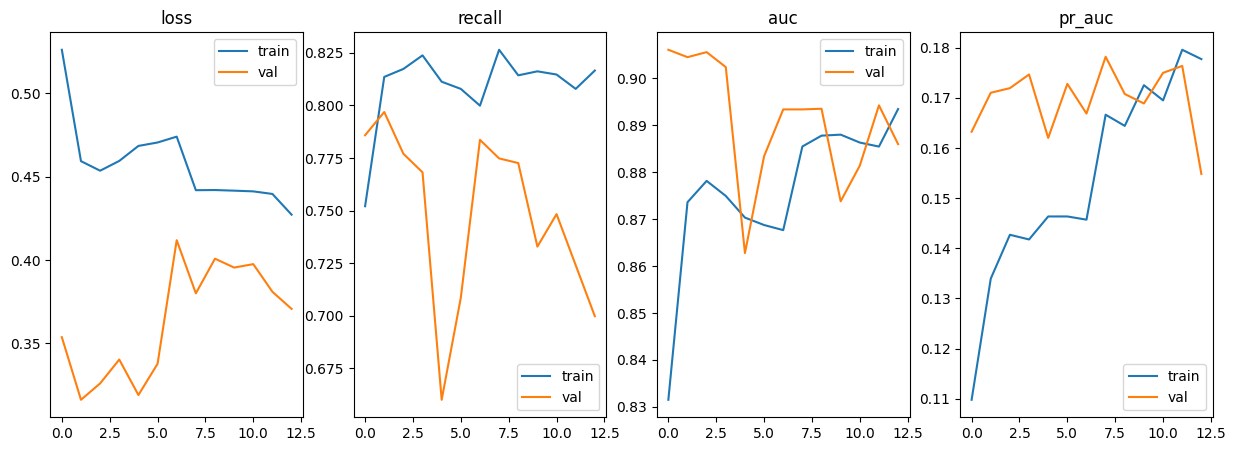

In [30]:
early_stop = EarlyStopping(monitor='val_pr_auc', patience=5, mode='max', restore_best_weights=True)
checkpoint = ModelCheckpoint('best_pivot_model.keras', monitor='val_pr_auc', mode='max', save_best_only=True)

reduce_lr = ReduceLROnPlateau(monitor='val_pr_auc', mode='max', factor=0.5,
                              patience=3, min_lr=1e-5)

history = model.fit(X_train, y_train, epochs=200, batch_size=64,
                    validation_data=(X_val, y_val), class_weight=class_weights_dict,
                    callbacks=[early_stop, checkpoint, reduce_lr], verbose=1)

plt.figure(figsize=(15, 5))
for i, m in enumerate(['loss', 'recall', 'auc', 'pr_auc'], 1):
    plt.subplot(1, 4, i)
    plt.plot(history.history[m], label='train')
    plt.plot(history.history['val_' + m], label='val')
    plt.title(m)
    plt.legend()
plt.show()

## M1 - Evaluation

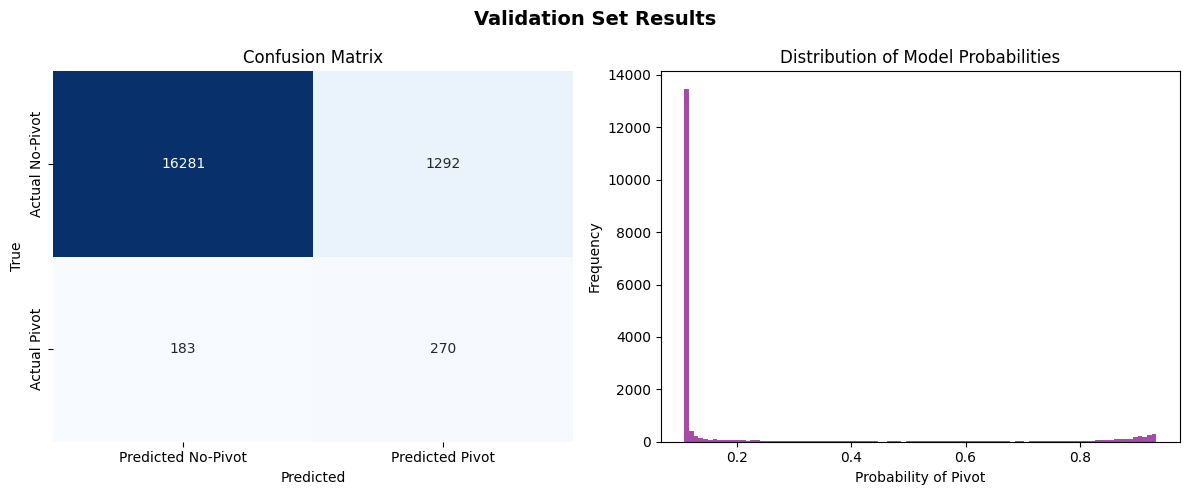

Validation Classification Report
              precision    recall  f1-score   support

    No-Pivot       0.99      0.93      0.96     17573
       Pivot       0.17      0.60      0.27       453

    accuracy                           0.92     18026
   macro avg       0.58      0.76      0.61     18026
weighted avg       0.97      0.92      0.94     18026



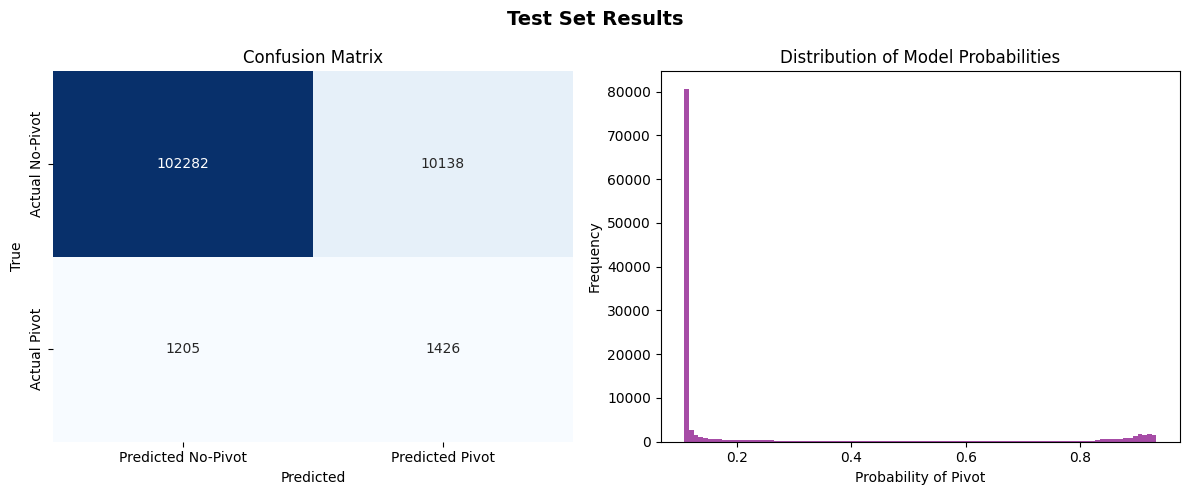

Test Classification Report
              precision    recall  f1-score   support

    No-Pivot       0.99      0.91      0.95    112420
       Pivot       0.12      0.54      0.20      2631

    accuracy                           0.90    115051
   macro avg       0.56      0.73      0.57    115051
weighted avg       0.97      0.90      0.93    115051



In [31]:
for name, X_data, y_data in [('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    y_prob = model.predict(X_data, verbose=1)
    y_pred = (y_prob >= M1_THRESHOLD).astype(int)

    plt.figure(figsize=(12, 5))
    plt.suptitle(f'{name} Set Results', fontsize=14, fontweight='bold')
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_data, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted No-Pivot', 'Predicted Pivot'],
                yticklabels=['Actual No-Pivot', 'Actual Pivot'])
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.subplot(1, 2, 2)
    plt.hist(y_prob, bins=100, color='purple', alpha=0.7)
    plt.title('Distribution of Model Probabilities')
    plt.xlabel('Probability of Pivot')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    print(f"{name} Classification Report")
    print(classification_report(y_data, y_pred, target_names=['No-Pivot', 'Pivot']))

## M1->M2 Handoff

In [32]:
shutil.copy('best_pivot_model.keras', 'M1-T0_8500.keras')
shutil.copy('libs/splits.json', 'splits.json')
print("best_pivot_model.keras  -->  M1-T0_8500.keras")
print("libs/splits.json        -->  splits.json")

best_pivot_model.keras  -->  M1-T0_8500.keras
libs/splits.json        -->  splits.json


# M2 (Tree Directional)

## Load data

In [ ]:
start_time = "2022-02-01 00:00:00"
end_time   = "2026-09-10 00:00:00"

FILEPATH = 'libs/BTCUSDT-M5.csv'

df = pd.read_csv(FILEPATH, index_col=0, parse_dates=True)
df.index = pd.to_datetime(df.index, unit='s', errors='coerce')

df = df[(df.index >= start_time) & (df.index <= end_time)]

df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 484270 entries, 2022-02-01 00:00:00+00:00 to 2026-09-09 23:55:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Volume  484270 non-null  int64  
 1   Open    484270 non-null  float64
 2   High    484270 non-null  float64
 3   Low     484270 non-null  float64
 4   Close   484270 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 22.2 MB


## M2 - Extended Kalman Filter

In [34]:
# Reuse the same causal filter and settings as M1 on the newly loaded candles.
df = ekf.run(df, target_lag=0)

Same as M1 - Extended Kalman Filter

In [ ]:
df = df[['Open', 'High', 'Low', 'Close', 'Volume', 'vol_estimate', 'q_multiplier',
         'norm_innovation', 'signed_observation_surprise',
         'level_uncertainty_norm', 'velocity_uncertainty_norm', 'filtered_velocity', 'target_price', 'target_velocity',
         'open', 'low', 'close', 'high',
         'mode_prob_responsive', 'vol_process','dir_ratio', 'robust_scale']]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 484270 entries, 2022-02-01 00:00:00+00:00 to 2026-09-09 23:55:00+00:00
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Open                         484270 non-null  float64
 1   High                         484270 non-null  float64
 2   Low                          484270 non-null  float64
 3   Close                        484270 non-null  float64
 4   Volume                       484270 non-null  int64  
 5   vol_estimate                 484270 non-null  float64
 6   q_multiplier                 484270 non-null  float64
 7   norm_innovation              484270 non-null  float64
 8   signed_observation_surprise  484270 non-null  float64
 9   level_uncertainty_norm       484270 non-null  float64
 10  velocity_uncertainty_norm    484270 non-null  float64
 11  filtered_velocity            484270 non-null  float64
 12  target_price

## M2 - M1 Predictions

In [36]:
# Reuse the M1 feature order and scaling settings.
with open('splits.json', 'r') as f:
    m1_settings = json.load(f)
feature_cols = m1_settings['feature_cols']
SEQ_LEN = m1_settings['seq_len']
ROLLING_SPAN = m1_settings['rolling_span']
threshold = float(m1_settings['m1_threshold'])
threshold = 0.88
df = engineer_m1_features(df)
df = scale_model_features(df, feature_cols, m1_settings['affine_features'],
                          ROLLING_SPAN, m1_settings['z_clip'])
end_rows = valid_window_ends(df, feature_cols, SEQ_LEN)
model = load_model('M1-T0_8500.keras')
if model.input_shape[-1] != len(feature_cols):
    raise ValueError('The saved M1 model uses different inputs. Run M1 training and handoff first.')
X_scaled = tf.convert_to_tensor(df[feature_cols].to_numpy(dtype=np.float32))
offsets = tf.range(SEQ_LEN - 1, -1, -1, dtype=tf.int64)
X_inference = tf.data.Dataset.from_tensor_slices(end_rows.astype(np.int64)).batch(1024)
X_inference = X_inference.map(lambda ends: tf.gather(X_scaled, ends[:, None] - offsets[None, :]))
X_inference = X_inference.prefetch(tf.data.AUTOTUNE)
y_prob = model.predict(X_inference, verbose=1).ravel() if len(end_rows) else np.empty(0)
df['predicted_prob'] = np.nan
df.loc[df.index[end_rows], 'predicted_prob'] = y_prob
df['predicted_signal'] = np.nan
df.loc[df.index[end_rows], 'predicted_signal'] = (y_prob >= threshold).astype(int)
print(f"Total Rows: {len(df)}")
print(f"Signals Triggered : {np.nansum(df['predicted_signal'].values)}")

Total Rows: 484270
Signals Triggered : 35853.0


In [37]:
def dedup_signals(df, thresh, gap=None):
    gap = int(m1_settings['m1_signal_gap']) if gap is None else gap
    d = df.copy()
    d['__row'] = np.arange(len(d))
    sub = d[d['predicted_prob'] >= thresh]
    sub = sub[~sub.index.duplicated(keep='first')]
    keep, last = [], None
    for timestamp in sub.index:
        if last is None or timestamp - last > gap * pd.Timedelta(ekf.bar_interval):
            keep.append(True)
            last = timestamp
        else:
            keep.append(False)
    keep = np.array(keep, dtype=bool)
    return sub[keep].drop(columns='__row').copy(), sub.index[keep], sub.index[~keep]

deduped, kept_ts, dropped_ts = dedup_signals(df, threshold)

print(f"Deduped signals: {len(deduped)} / {len(df)} candles "
      f"({100 * len(deduped) / len(df):.2f}%)\n")

# signals as % of candles, month by month
candles_pm = df.groupby(df.index.to_period('M')).size()
signals_pm = deduped.groupby(deduped.index.to_period('M')).size()
monthly = pd.DataFrame({'candles': candles_pm, 'signals': signals_pm}).fillna(0).astype(int)
monthly['signal_%'] = 100 * monthly['signals'] / monthly['candles']
print(monthly.to_string(float_format='%.2f'))

Deduped signals: 14726 / 484270 candles (3.04%)

          candles  signals  signal_%
DateTime                            
2022-02      8064      217      2.69
2022-03      8928      234      2.62
2022-04      8640      271      3.14
2022-05      8928      232      2.60
2022-06      8640      237      2.74
2022-07      8928      256      2.87
2022-08      8928      235      2.63
2022-09      8640      210      2.43
2022-10      8928      237      2.65
2022-11      8640      222      2.57
2022-12      8928      266      2.98
2023-01      8928      275      3.08
2023-02      8064      218      2.70
2023-03      8912      247      2.77
2023-04      8640      250      2.89
2023-05      8928      262      2.93
2023-06      8640      261      3.02
2023-07      8928      320      3.58
2023-08      8928      321      3.60
2023-09      8640      266      3.08
2023-10      8928      308      3.45
2023-11      8640      261      3.02
2023-12      8928      265      2.97
2024-01      8928      291

/tmp/ipykernel_6163/2934978789.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  candles_pm = df.groupby(df.index.to_period('M')).size()
/tmp/ipykernel_6163/2934978789.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  signals_pm = deduped.groupby(deduped.index.to_period('M')).size()


### Inspect labels

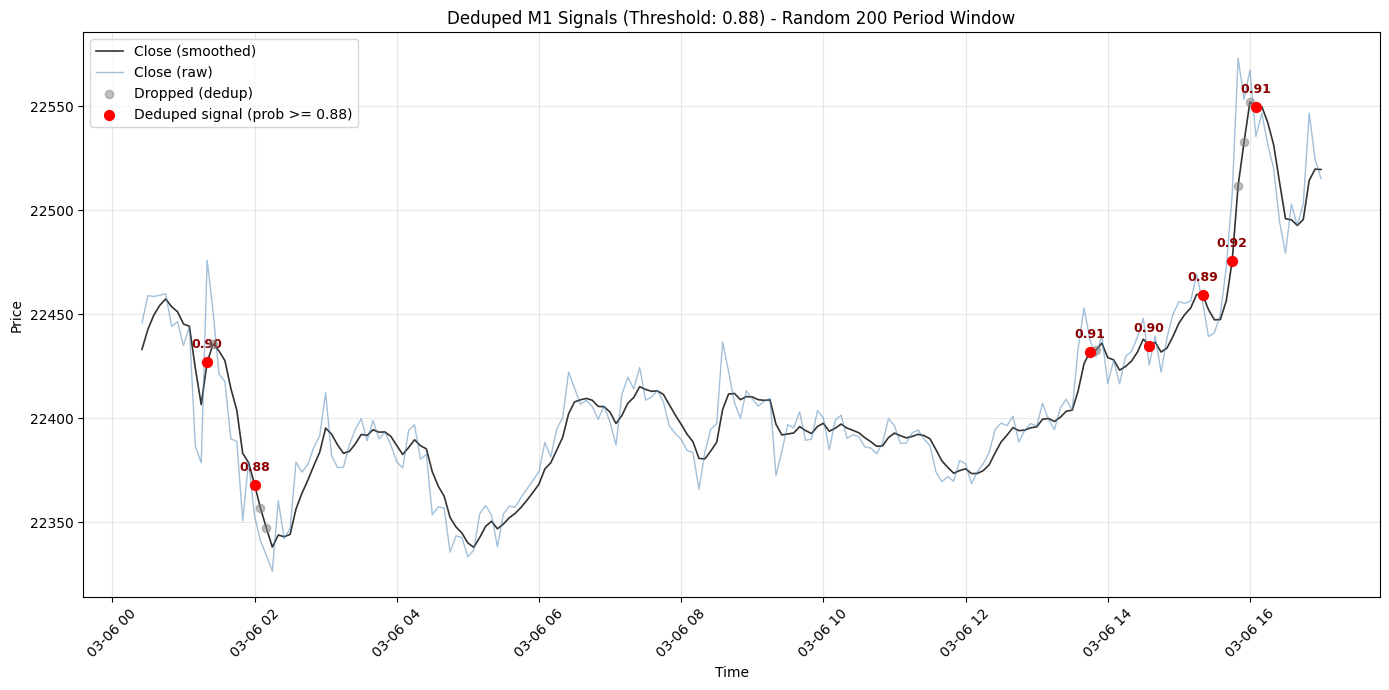

In [38]:
WINDOW_SIZE = 200

deduped, kept_ts, dropped_ts = dedup_signals(df, threshold)

max_start = len(df) - WINDOW_SIZE
start_idx = random.randint(0, max_start) if max_start > 0 else 0
subset = df.iloc[start_idx:start_idx + WINDOW_SIZE]

plt.figure(figsize=(14, 7))
plt.plot(subset.index, subset['Close'], label='Close (smoothed)',
         color='black', alpha=0.8, linewidth=1.2)
plt.plot(subset.index, subset['close'], label='Close (raw)',
         color='steelblue', alpha=0.5, linewidth=1)

kept_w = subset[subset.index.isin(kept_ts)]
drop_w = subset[subset.index.isin(dropped_ts)]

if len(drop_w):
    plt.scatter(drop_w.index, drop_w['Close'], color='grey', alpha=0.5,
                label='Dropped (dedup)', s=35, zorder=4)
plt.scatter(kept_w.index, kept_w['Close'], color='red',
            label=f'Deduped signal (prob >= {threshold})', s=50, zorder=5)

for time, row in kept_w.iterrows():
    plt.annotate(f"{float(row['predicted_prob']):.2f}", xy=(time, row['Close']),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.title(f"Deduped M1 Signals (Threshold: {threshold}) - Random {WINDOW_SIZE} Period Window")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
df = df[['Open', 'Close', 'Low', 'High', 'Volume', 'predicted_prob',
         'predicted_signal', 'vol_estimate', 'q_multiplier', 'norm_innovation', 'signed_observation_surprise',
         'level_uncertainty_norm', 'velocity_uncertainty_norm',
         'filtered_velocity', 'target_price', 'target_velocity',
         'open', 'low', 'close', 'high',
         'mode_prob_responsive', 'vol_process','dir_ratio', 'robust_scale']]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 484270 entries, 2022-02-01 00:00:00+00:00 to 2026-09-09 23:55:00+00:00
Data columns (total 24 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Open                         484270 non-null  float64
 1   Close                        484270 non-null  float64
 2   Low                          484270 non-null  float64
 3   High                         484270 non-null  float64
 4   Volume                       484270 non-null  int64  
 5   predicted_prob               483628 non-null  float64
 6   predicted_signal             483628 non-null  float64
 7   vol_estimate                 484270 non-null  float64
 8   q_multiplier                 484270 non-null  float64
 9   norm_innovation              484270 non-null  float64
 10  signed_observation_surprise  484270 non-null  float64
 11  level_uncertainty_norm       484270 non-null  float64
 12  velocity_unc

## M2 - Class Y

In [40]:
M2_LABEL_HORIZON = 120
M2_BARRIER_MULT = 4.0
M2_TARGET_SOURCE = 'smoothed'
label_segments = df.index.to_series().diff().ne(pd.Timedelta(ekf.bar_interval)).cumsum()

def atr(frame, h, l, c, period=100):
    def calculate(part):
        previous = part[c].shift()
        tr = pd.concat([part[h] - part[l], (part[h] - previous).abs(),
                        (part[l] - previous).abs()], axis=1).max(axis=1)
        return tr.rolling(period).mean()
    return pd.concat([calculate(part) for _, part in frame.groupby(label_segments, sort=False)])

df['ATR_smoothed'] = atr(df, 'High', 'Low', 'Close')
df['ATR_raw'] = atr(df, 'high', 'low', 'close')

def label_triple_barrier(frame, signal_ts, h_col, l_col, c_col, atr_col,
                         barrier_mult=M2_BARRIER_MULT, time_limit=M2_LABEL_HORIZON):
    h, l, c, a = (frame[col].to_numpy() for col in [h_col, l_col, c_col, atr_col])
    segments = frame.index.to_series().diff().ne(pd.Timedelta(ekf.bar_interval)).cumsum().to_numpy()
    positions = frame.index.get_indexer(signal_ts)
    out = np.full(len(signal_ts), -1, dtype=int)
    status = np.full(len(signal_ts), 'missing_future', dtype=object)
    label_end = [pd.NaT] * len(signal_ts)
    for k, i in enumerate(positions):
        if i < 0 or not np.isfinite(c[i]) or not np.isfinite(a[i]) or a[i] <= 0:
            status[k] = 'invalid_start'
            continue
        last = i + time_limit
        if last >= len(frame) or segments[i] != segments[last]:
            continue
        label_end[k] = frame.index[last]
        future_h, future_l = h[i + 1:last + 1], l[i + 1:last + 1]
        if not (np.isfinite(future_h).all() and np.isfinite(future_l).all()):
            continue
        upper, lower = c[i] + a[i] * barrier_mult, c[i] - a[i] * barrier_mult
        up = np.flatnonzero(future_h >= upper)
        down = np.flatnonzero(future_l <= lower)
        if len(up) and len(down) and up[0] == down[0]:
            status[k] = 'ambiguous_order'
        elif len(up) and (not len(down) or up[0] < down[0]):
            out[k], status[k] = 1, 'upper_first'
        elif len(down):
            out[k], status[k] = 0, 'lower_first'
        else:
            status[k] = 'timeout'
    return out, status, pd.DatetimeIndex(label_end)

filtered, _, _ = dedup_signals(df, threshold)
sig_ts = filtered.index
for name, columns in [('smoothed', ('High', 'Low', 'Close', 'ATR_smoothed')),
                      ('raw', ('high', 'low', 'close', 'ATR_raw'))]:
    target, status, label_end = label_triple_barrier(df, sig_ts, *columns)
    filtered[f'target_{name}'] = target
    filtered[f'status_{name}'] = status
    filtered[f'label_end_{name}'] = label_end

# Keep the chosen target's known outcomes, independently of the other price path.
resolved = filtered['target_smoothed'].isin([0, 1]) & filtered['target_raw'].isin([0, 1])
usable = filtered[f'target_{M2_TARGET_SOURCE}'].isin([0, 1])
final_training_data = filtered.loc[usable].copy()
final_training_data['target'] = final_training_data[f'target_{M2_TARGET_SOURCE}'].astype(int)
final_training_data['label_end'] = final_training_data[f'label_end_{M2_TARGET_SOURCE}']
flip_mask = resolved & (filtered['target_smoothed'] != filtered['target_raw'])
n_flipped = int(flip_mask.sum())
n_unres = int((~usable).sum())
print(f"Original M1 signals (after dedup):  {len(filtered)}")
print(f"  Both resolved by triple barrier:   {resolved.sum()}")
print(f"  Dropped - unknown/timeout/tie:      {n_unres}")
print(f"  Kept   - total (smoothed labels):  {len(final_training_data)}")
print(f"    raw disagrees (both resolved):   {n_flipped}")
print(f"    raw agrees (both resolved):      {int(resolved.sum()) - n_flipped}")
print(filtered[f'status_{M2_TARGET_SOURCE}'].value_counts().to_string())
print(f"\nClass balance in training data:")
n_long = (final_training_data['target'] == 1).sum()
n_short = (final_training_data['target'] == 0).sum()
n_usable = max(len(final_training_data), 1)
print(f"  Long  (1): {n_long:>5}  ({100 * n_long / n_usable:.1f}%)")
print(f"  Short (0): {n_short:>5}  ({100 * n_short / n_usable:.1f}%)")

Original M1 signals (after dedup):  14726
  Both resolved by triple barrier:   13738
  Dropped - unknown/timeout/tie:      800
  Kept   - total (smoothed labels):  13926
    raw disagrees (both resolved):   1510
    raw agrees (both resolved):      12228
status_smoothed
upper_first        7037
lower_first        6889
timeout             785
missing_future        8
ambiguous_order       7

Class balance in training data:
  Long  (1):  7037  (50.5%)
  Short (0):  6889  (49.5%)


In [41]:
agr = pd.DataFrame({
    'month': filtered.index.to_period('M'),
    'resolved': resolved.values,
    'agreed': (resolved & (filtered['target_smoothed'] == filtered['target_raw'])).values,
})
monthly = agr.groupby('month').agg(
    signals=('agreed', 'size'),
    resolved=('resolved', 'sum'),
    agreed=('agreed', 'sum'),
)
monthly['agree_%_of_signals'] = 100 * monthly['agreed'] / monthly['signals']
monthly['agree_%_of_resolved'] = 100 * monthly['agreed'] / monthly['resolved']

print(monthly.to_string(float_format='%.1f'))
print(f"\nOverall: {monthly['agreed'].sum()}/{monthly['signals'].sum()} "
      f"= {100 * monthly['agreed'].sum() / monthly['signals'].sum():.1f}% of signals "
      f"({100 * monthly['agreed'].sum() / monthly['resolved'].sum():.1f}% of resolved)")

         signals  resolved  agreed  agree_%_of_signals  agree_%_of_resolved
month                                                                      
2022-02      217       201     182                83.9                 90.5
2022-03      234       228     194                82.9                 85.1
2022-04      271       244     220                81.2                 90.2
2022-05      232       210     183                78.9                 87.1
2022-06      237       221     204                86.1                 92.3
2022-07      256       225     208                81.2                 92.4
2022-08      235       210     188                80.0                 89.5
2022-09      210       184     159                75.7                 86.4
2022-10      237       206     181                76.4                 87.9
2022-11      222       203     176                79.3                 86.7
2022-12      266       230     210                78.9                 91.3
2023-01     

/tmp/ipykernel_6163/3784057136.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  'month': filtered.index.to_period('M'),


## M2 - Feature engineering

In [42]:
def engineer_features_v3(frame):
    data = engineer_m1_features(frame)
    segments = data.index.to_series().diff().ne(pd.Timedelta(ekf.bar_interval)).cumsum()
    p_m1 = data['predicted_prob']
    data['feat_m1_prob'] = p_m1
    data['feat_m1_prob_slope12'] = p_m1.groupby(segments).diff(12)
    data['feat_m1_prob_change'] = p_m1.groupby(segments).diff()
    # Time since the previous retained activation; the current event cannot reset its own age.
    event_time = data.index.to_series().where(data.index.isin(kept_ts))
    previous_event = event_time.groupby(segments).transform(lambda x: x.ffill().shift(1))
    elapsed_bars = (data.index.to_series() - previous_event) / pd.Timedelta(ekf.bar_interval)
    data['feat_m1_signal_age'] = np.log1p(elapsed_bars)
    feature_list = [c for c in data if c.startswith('feat_')]
    return data.replace([np.inf, -np.inf], np.nan), feature_list

df_features, feature_list = engineer_features_v3(df)
print(f"Total Features: {len(feature_list)}")
print(feature_list)

Total Features: 54
['feat_bb_width', 'feat_atr_norm', 'feat_dc_width', 'feat_dc_position20', 'feat_dist_high_atr20', 'feat_dist_low_atr20', 'feat_rsi', 'feat_rsi_roc', 'feat_macd_hist', 'feat_roc_3', 'feat_roc_12', 'feat_log_ret_6', 'feat_log_ret_24', 'feat_log_ret_60', 'feat_hist_vol', 'feat_ema_spread', 'feat_body_dominance', 'feat_signed_body_ratio', 'feat_upper_wick_ratio', 'feat_lower_wick_ratio', 'feat_close_location', 'feat_bars_since_high20', 'feat_bars_since_low20', 'feat_raw_filtered_gap_norm', 'feat_raw_filtered_ret_diff', 'feat_raw_filtered_range_ratio', 'feat_rvol', 'feat_vroc', 'feat_vol_std', 'feat_vol_price_corr', 'feat_innov_norm', 'feat_innov_ema', 'feat_innov_autocorr', 'feat_innov_mag', 'feat_signed_observation_surprise', 'feat_level_uncertainty', 'feat_velocity_uncertainty', 'feat_velocity_norm', 'feat_accel_norm', 'feat_velocity_change6', 'feat_vol_ratio', 'feat_vol_change', 'feat_dir_consistency', 'feat_ekf_log_ret', 'feat_mode_prob_responsive', 'feat_mode_prob_r

## M2 - Scaling & Tabular Features

In [ ]:
with open('splits.json', 'r') as f: splits = json.load(f)

SEQ_LEN          = splits['seq_len']
ROLLING_SPAN     = splits['rolling_span']
M1_LABEL_HORIZON = splits['label_horizon']
LABEL_HORIZON_M2 = M2_LABEL_HORIZON
EMBARGO_M2       = 60

EXTRA_PURGE_BARS = max(0, LABEL_HORIZON_M2 - M1_LABEL_HORIZON)

def _parse_slices(slice_list):
    out = []
    for s in slice_list:
        out.append((pd.Timestamp(s['start']), pd.Timestamp(s['end'])))
    return out

m2_train_slices = _parse_slices(splits['slices_ts']['m2_train'])
m2_val_slices   = _parse_slices(splits['slices_ts']['m2_val'])
test_slices     = _parse_slices(splits['slices_ts']['test'])

print(f"Loaded splits:")
print(f"  M2-TRAIN slices: {len(m2_train_slices)}")
print(f"  M2-VAL   slices: {len(m2_val_slices)}")
print(f"  TEST     slices: {len(test_slices)}")

feature_list = [c for c in df_features.columns if 'feat_' in c]
target_col = 'target'

df_scaled = df_features.copy()
Z_CLIP = 8.0


M2_AFFINE_FEATURES = dict(M1_AFFINE_FEATURES)
M2_AFFINE_FEATURES.update({
    'feat_m1_prob': (1.0, -0.5),
    'feat_m1_prob_slope12': (1.0, 0.0),
    'feat_m1_prob_change': (1.0, 0.0),
    'feat_m1_signal_age': (0.2, 0.0),
})
df_scaled = scale_model_features(df_features, feature_list, M2_AFFINE_FEATURES,
                                 ROLLING_SPAN, Z_CLIP)
# Missing feature rows stay missing; windows spanning them are excluded below.


def _mask_from_slices(ts_index, slices, extra_tail_purge=0):
    mask = pd.Series(False, index=ts_index)
    for (s, e) in slices:
        e_adj = e - pd.Timedelta(minutes=5 * extra_tail_purge)
        mask |= (ts_index >= s) & (ts_index <= e_adj)
    return mask.values

sig_ts = final_training_data.index
valid_in_scaled = sig_ts.isin(df_scaled.index)

mask_m2_train = _mask_from_slices(sig_ts, m2_train_slices, extra_tail_purge=EXTRA_PURGE_BARS) & valid_in_scaled
mask_m2_val   = _mask_from_slices(sig_ts, m2_val_slices,   extra_tail_purge=EXTRA_PURGE_BARS) & valid_in_scaled
mask_test     = _mask_from_slices(sig_ts, test_slices,     extra_tail_purge=0) & valid_in_scaled  # no tail to purge

dropped = (~(mask_m2_train | mask_m2_val | mask_test)).sum()

print(f"\nSignal usage:")
print(f"  Total labeled signals:              {len(final_training_data)}")
print(f"  Dropped (in M1-TRAIN / M1-VAL):     {dropped}")
print(f"  → M2-TRAIN signals:                 {mask_m2_train.sum()}")
print(f"  → M2-VAL   signals:                 {mask_m2_val.sum()}")
print(f"  → TEST     signals:                 {mask_test.sum()}")

data_array  = df_scaled[feature_list].to_numpy(dtype=np.float32)
time_index  = df_scaled.index
time_to_idx = {t: i for i, t in enumerate(time_index)}

# Both models predict after the signal candle closes; include that candle.
eligible_m2_ends = set(valid_window_ends(df_scaled, feature_list, SEQ_LEN))
def _build_windows(signal_df):
    Xs, ys, ts = [], [], []
    for timestamp, row in signal_df.iterrows():
        i = time_to_idx.get(timestamp)
        if i is None or i not in eligible_m2_ends:
            continue
        seq = data_array[i - SEQ_LEN + 1:i + 1]
        if seq.shape[0] != SEQ_LEN:
            continue
        Xs.append(seq)
        ys.append(int(row[target_col]))
        ts.append(timestamp)
    if not Xs:
        return (np.empty((0, SEQ_LEN, len(feature_list))),
                np.empty((0,), dtype=int),
                pd.DatetimeIndex([]))
    return np.array(Xs), np.array(ys, dtype=int), pd.DatetimeIndex(ts)


# Summarize each window as levels, changes and variability.
TAB_MODE = 'summary'   # 'summary' = level + deltas + window stats | 'last' = signal-bar row only

assert SEQ_LEN >= 21, "summary descriptors need at least 21 bars of window"

_SUMMARY_SPECS = [
    ('last',     lambda w: w[:, -1, :]),                    # most recent bar in the window
    ('delta_5',  lambda w: w[:, -1, :] - w[:,  -6, :]),      # short-horizon change
    ('delta_20', lambda w: w[:, -1, :] - w[:, -21, :]),      # medium-horizon change
    ('std_60',   lambda w: w.std(axis=1)),
]
_LAST_SPECS = [('last', lambda w: w[:, -1, :])]

def to_tabular(seq3d, base_names, mode=TAB_MODE):
    specs = _SUMMARY_SPECS if mode == 'summary' else _LAST_SPECS
    names = [f'{b}__{sname}' for sname, _ in specs for b in base_names]
    if seq3d.shape[0] == 0:
        return np.empty((0, len(names)), dtype=np.float64), names
    w = np.asarray(seq3d, dtype=np.float64)
    return np.concatenate([fn(w) for _, fn in specs], axis=1), names


sigs_m2_train = final_training_data[mask_m2_train]
sigs_m2_val   = final_training_data[mask_m2_val]
sigs_test     = final_training_data[mask_test]

Xw_train, y_train, ts_m2_train = _build_windows(sigs_m2_train)
Xw_val,   y_val,   ts_m2_val   = _build_windows(sigs_m2_val)
Xw_test,  y_test,  ts_m2_test  = _build_windows(sigs_test)

X_train, tab_feature_names = to_tabular(Xw_train, feature_list)
X_val,   _                 = to_tabular(Xw_val,   feature_list)
X_test,  _                 = to_tabular(Xw_test,  feature_list)

print(f"\nWindows (pre-flattening):")
print(f"  Xw_train: {Xw_train.shape}   Xw_val: {Xw_val.shape}   Xw_test: {Xw_test.shape}")
print(f"\nTabular design matrices  (mode='{TAB_MODE}', "
      f"{len(feature_list)} base features x {len(tab_feature_names)//max(len(feature_list),1)} descriptors):")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"  rows per column in TRAIN: {X_train.shape[0] / max(X_train.shape[1], 1):.1f}")


# Separate chronological roles inside validation, with complete label windows.
val_start, val_end = m2_val_slices[0][0], m2_val_slices[-1][1]
stop_end = val_start + (val_end - val_start) * 0.40
calibration_end = val_start + (val_end - val_start) * 0.70
val_label_end = final_training_data.loc[ts_m2_val, 'label_end']
val_stop_mask = np.asarray((ts_m2_val < stop_end) & (val_label_end < stop_end))
val_cal_mask = np.asarray((ts_m2_val >= stop_end) & (ts_m2_val < calibration_end)
                          & (val_label_end < calibration_end))
val_select_mask = np.asarray(ts_m2_val >= calibration_end)
X_stop, y_stop = X_val[val_stop_mask], y_val[val_stop_mask]
X_cal, y_cal = X_val[val_cal_mask], y_val[val_cal_mask]
X_select, y_select = X_val[val_select_mask], y_val[val_select_mask]
ts_select = ts_m2_val[val_select_mask]
for role, labels in [('M2 training', y_train), ('stopping', y_stop),
                     ('calibration', y_cal), ('threshold selection', y_select)]:
    if len(labels) < 30 or len(np.unique(labels)) < 2:
        raise ValueError(f'{role} needs at least 30 usable events and both directions; provide more history.')

def calendar_from_slices(slices):
    calendar = pd.DatetimeIndex([])
    for start, end in slices:
        calendar = calendar.union(pd.date_range(start.normalize(), end.normalize(), freq='D'))
    return calendar

selection_slices = [(calibration_end, val_end)]
print(f"Validation roles: {len(y_stop)} stopping / {len(y_cal)} calibration / {len(y_select)} thresholds")
print(f"\nM2-TRAIN positive class: {100.0 * (y_train == 1).mean():.2f}%")
print(f"M2-VAL   positive class: {100.0 * (y_val == 1).mean():.2f}%")
print(f"TEST     positive class: {100.0 * (y_test == 1).mean():.2f}%")

Loaded splits:
  M2-TRAIN slices: 1
  M2-VAL   slices: 1
  TEST     slices: 1

Signal usage:
  Total labeled signals:              13926
  Dropped (in M1-TRAIN / M1-VAL):     3323
  → M2-TRAIN signals:                 4369
  → M2-VAL   signals:                 2733
  → TEST     signals:                 3501

Windows (pre-flattening):
  Xw_train: (4369, 60, 54)   Xw_val: (2729, 60, 54)   Xw_test: (3501, 60, 54)

Tabular design matrices  (mode='summary', 54 base features x 4 descriptors):
  X_train: (4369, 216)   y_train: (4369,)
  X_val:   (2729, 216)   y_val:   (2729,)
  X_test:  (3501, 216)   y_test:  (3501,)
  rows per column in TRAIN: 20.2
Validation roles: 1047 stopping / 798 calibration / 876 thresholds

M2-TRAIN positive class: 50.65%
M2-VAL   positive class: 50.64%
TEST     positive class: 49.81%


## M2 - XGBoost Ensemble

     Split  Mean seed AUC  Ensemble AUC
Validation         0.6383        0.6388
      Test         0.6600        0.6623


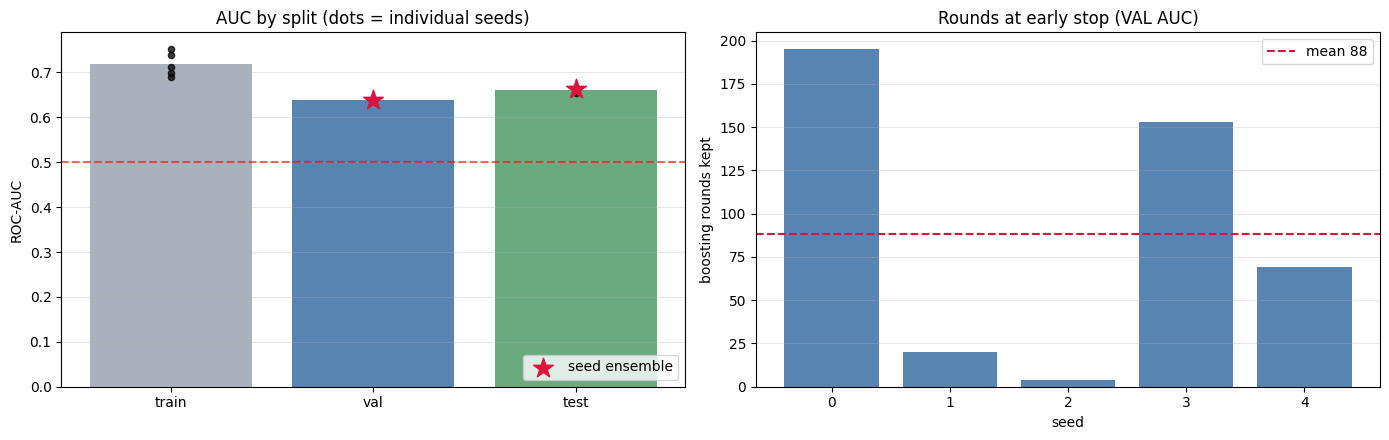

In [44]:
import time
import warnings
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss, brier_score_loss

SEEDS        = [0, 1, 2, 3, 4]
FINAL_FAMILY = 'xgboost'      

# Balance the training classes.
_w  = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
_cw = dict(zip(np.unique(y_train), _w))
sw_train = np.array([_cw[v] for v in y_train], dtype=np.float64)


XGB_PARAMS = dict(
    n_estimators=3000, learning_rate=0.02, max_depth=3,
    min_child_weight=20, subsample=0.8, colsample_bytree=0.8,
    reg_lambda=10.0, gamma=0.0,
    objective='binary:logistic', eval_metric='auc',
    tree_method='hist',
    importance_type='gain', n_jobs=-1,
)

def _fit_xgb(seed):
    stop = xgb.callback.EarlyStopping(rounds=100, metric_name='auc',
                                      data_name='validation_1', maximize=True, save_best=True)
    m = xgb.XGBClassifier(random_state=seed, callbacks=[stop], **XGB_PARAMS)
    # Record training metrics; stop on the reserved validation block.
    m.fit(X_train, y_train, sample_weight=sw_train,
          eval_set=[(X_train, y_train), (X_stop, y_stop)], verbose=False)
    return m, int(getattr(m, 'best_iteration', m.n_estimators) or 0) + 1

BUILDERS = {'xgboost': _fit_xgb}


def _scores(m, X, y):
    p = m.predict_proba(X)[:, 1]
    return {'auc':   roc_auc_score(y, p),
            'acc':   accuracy_score(y, (p >= 0.5).astype(int)),
            'brier': brier_score_loss(y, p),
            'logloss': log_loss(y, np.clip(p, 1e-6, 1 - 1e-6))}, p

fitted, rows = {}, []
train_probs, val_probs, test_probs = {}, {}, {}
evals_history = {}

for fam, builder in BUILDERS.items():
    fitted[fam], train_probs[fam], val_probs[fam], test_probs[fam] = [], [], [], []
    for seed in SEEDS:
        t0 = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m, n_trees = builder(seed)
        r, pr = _scores(m, X_train, y_train)
        v, pv = _scores(m, X_val,   y_val)
        t, pt = _scores(m, X_test,  y_test)
        fitted[fam].append(m)
        train_probs[fam].append(pr); val_probs[fam].append(pv); test_probs[fam].append(pt)
        try:
            evals_history[seed] = m.evals_result()
        except Exception:
            evals_history[seed] = {}
        rows.append({'family': fam, 'seed': seed, 'trees': n_trees,
                     'train_auc': r['auc'],
                     'val_auc': v['auc'], 'val_acc': v['acc'],
                     'val_logloss': v['logloss'], 'val_brier': v['brier'],
                     'test_auc': t['auc'], 'test_acc': t['acc'],
                     'fit_s': time.time() - t0})

bench = pd.DataFrame(rows)

# Average all seeds without selecting a best seed.
ens = []
for fam in BUILDERS:
    pr = np.mean(train_probs[fam], axis=0)
    pv = np.mean(val_probs[fam], axis=0)
    pt = np.mean(test_probs[fam], axis=0)
    ens.append({'family': fam,
                'train_auc_ens': roc_auc_score(y_train, pr),
                'val_auc_ens': roc_auc_score(y_val, pv),
                'val_acc_ens': accuracy_score(y_val, (pv >= 0.5).astype(int)),
                'test_auc_ens': roc_auc_score(y_test, pt),
                'test_acc_ens': accuracy_score(y_test, (pt >= 0.5).astype(int))})
ens = pd.DataFrame(ens).set_index('family')

summary = (bench.groupby('family')
                .agg(train_auc_mean=('train_auc', 'mean'),
                     val_auc_mean=('val_auc', 'mean'), val_auc_std=('val_auc', 'std'),
                     val_acc_mean=('val_acc', 'mean'),
                     val_logloss_mean=('val_logloss', 'mean'),
                     test_auc_mean=('test_auc', 'mean'), test_auc_std=('test_auc', 'std'),
                     test_acc_mean=('test_acc', 'mean'),
                     trees_mean=('trees', 'mean'))
                .join(ens[['val_auc_ens', 'test_auc_ens']])
                .sort_values('val_auc_mean', ascending=False))


metrics = pd.DataFrame({
    'Split': ['Validation', 'Test'],
    'Mean seed AUC': [summary.loc[FINAL_FAMILY, 'val_auc_mean'], summary.loc[FINAL_FAMILY, 'test_auc_mean']],
    'Ensemble AUC': [ens.loc[FINAL_FAMILY, 'val_auc_ens'], ens.loc[FINAL_FAMILY, 'test_auc_ens']],
})
print(metrics.round(4).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
_splits = ['train', 'val', 'test']
_means  = [summary.loc[FINAL_FAMILY, f'{s}_auc_mean'] for s in _splits]
ax[0].bar(_splits, _means, color=['#9aa5b1', '#3b6ea5', '#4f9d69'], alpha=0.85)
for j, s in enumerate(_splits):
    ax[0].scatter([j] * len(SEEDS), bench[f'{s}_auc'], color='black', zorder=5, s=20, alpha=0.75)
for j, s in enumerate(['val', 'test']):
    ax[0].scatter([j + 1], [ens.loc[FINAL_FAMILY, f'{s}_auc_ens']], marker='*', s=220,
                  color='crimson', zorder=6, label='seed ensemble' if j == 0 else None)
ax[0].axhline(0.5, color='red', ls='--', alpha=0.6)
ax[0].set_ylabel('ROC-AUC'); ax[0].set_title('AUC by split (dots = individual seeds)')
ax[0].grid(alpha=0.3, axis='y'); ax[0].legend(loc='lower right')

ax[1].bar([str(s) for s in SEEDS], bench['trees'], color='#3b6ea5', alpha=0.85)
ax[1].axhline(bench['trees'].mean(), color='crimson', ls='--',
              label=f"mean {bench['trees'].mean():.0f}")
ax[1].set_xlabel('seed'); ax[1].set_ylabel('boosting rounds kept')
ax[1].set_title('Rounds at early stop (VAL AUC)')
ax[1].grid(alpha=0.3, axis='y'); ax[1].legend()
plt.tight_layout(); plt.show()


class SeedEnsemble:
    """Average class probabilities across fitted seeds."""
    def __init__(self, models, name):
        self.models, self.name = models, name

    def predict_proba_1d(self, X):
        return np.mean([m.predict_proba(X)[:, 1] for m in self.models], axis=0)

    def predict_proba(self, X):
        p = self.predict_proba_1d(X)
        return np.column_stack([1.0 - p, p])

    def predict(self, X, verbose=0, **kwargs):
        return self.predict_proba_1d(X).reshape(-1, 1)

model = SeedEnsemble(fitted[FINAL_FAMILY], FINAL_FAMILY)
predict_prob_raw = model.predict_proba_1d

## Calibrating Probabilities

model     = xgboost (seed ensemble, n=5)
n_cal     = 798  ->  calibrator: PLATT
raw val probability range: [0.311, 0.707]

              Brier   LogLoss
       raw   0.2383    0.6690
     platt   0.2400    0.6719

These probability metrics use the later validation block; its labels did not fit calibration.


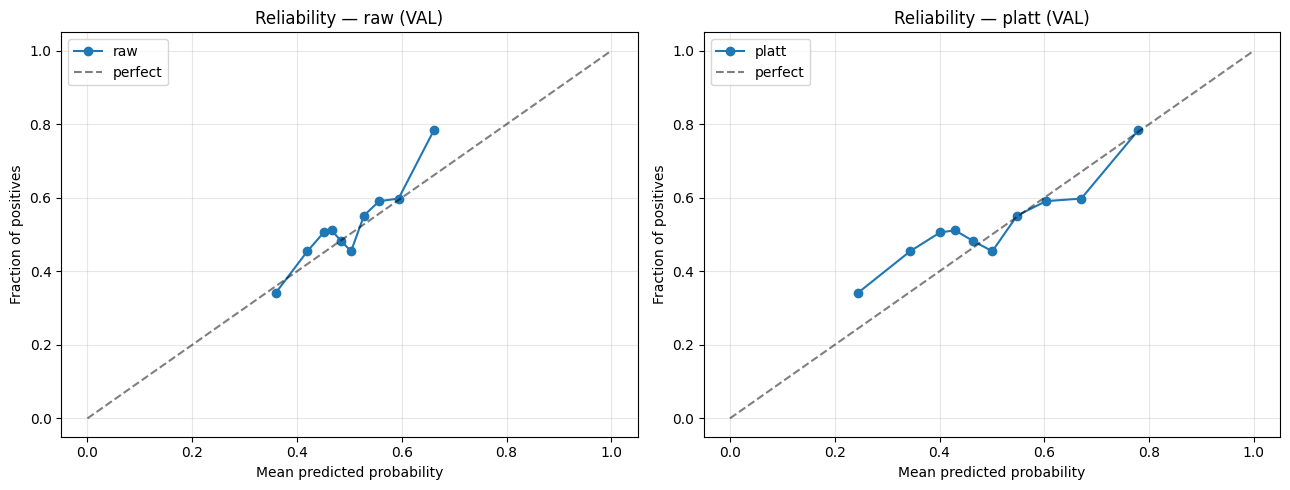

In [45]:
# Fit one smooth probability correction on the dedicated calibration block.
# Reliability is displayed on the later threshold block, outside calibration fitting.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import calibration_curve

_EPS = 1e-6
def _logit(p):
    p = np.clip(np.asarray(p, dtype=np.float64), _EPS, 1 - _EPS)
    return np.log(p / (1 - p))

cal_raw = np.asarray(predict_prob_raw(X_cal), dtype=np.float64).ravel()
platt_cal = LogisticRegression(C=1.0, solver='lbfgs').fit(_logit(cal_raw).reshape(-1, 1), y_cal)
# A negative slope would reverse the learned direction; keep the original ranking instead.
CALIBRATOR = 'platt' if platt_cal.coef_.ravel()[0] > 0 else 'raw'

def calibrate_probs(p_raw):
    p_raw = np.asarray(p_raw, dtype=np.float64).ravel()
    if CALIBRATOR == 'raw':
        return np.clip(p_raw, _EPS, 1 - _EPS)
    return np.clip(platt_cal.predict_proba(_logit(p_raw).reshape(-1, 1))[:, 1], _EPS, 1 - _EPS)

val_raw = np.asarray(predict_prob_raw(X_select), dtype=np.float64).ravel()
val_platt = calibrate_probs(val_raw)
print(f"model     = {getattr(model, 'name', type(model).__name__)} "
      f"(seed ensemble, n={len(getattr(model, 'models', []))})")
print(f"n_cal     = {len(y_cal)}  ->  calibrator: {CALIBRATOR.upper()}")
print(f"raw val probability range: [{val_raw.min():.3f}, {val_raw.max():.3f}]\n")
print(f"{'':>10} {'Brier':>8} {'LogLoss':>9}")
for name, p in [('raw', val_raw), (CALIBRATOR, val_platt)]:
    print(f"{name:>10} {brier_score_loss(y_select, p):>8.4f} {log_loss(y_select, p):>9.4f}")
print("\nThese probability metrics use the later validation block; its labels did not fit calibration.")
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, (name, p) in zip(ax, [('raw', val_raw), (CALIBRATOR, val_platt)]):
    frac_pos, mean_pred = calibration_curve(y_select, p, n_bins=10, strategy='quantile')
    a.plot(mean_pred, frac_pos, 'o-', label=name)
    a.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='perfect')
    a.set_xlabel('Mean predicted probability')
    a.set_ylabel('Fraction of positives')
    a.set_title(f'Reliability — {name} (VAL)')
    a.legend()
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluation

### Threshold choice

Top eight eligible pairs, ranked by the worst-side Wilson lower bound.

Chosen thresholds: short <= 0.2497, long >= 0.7178


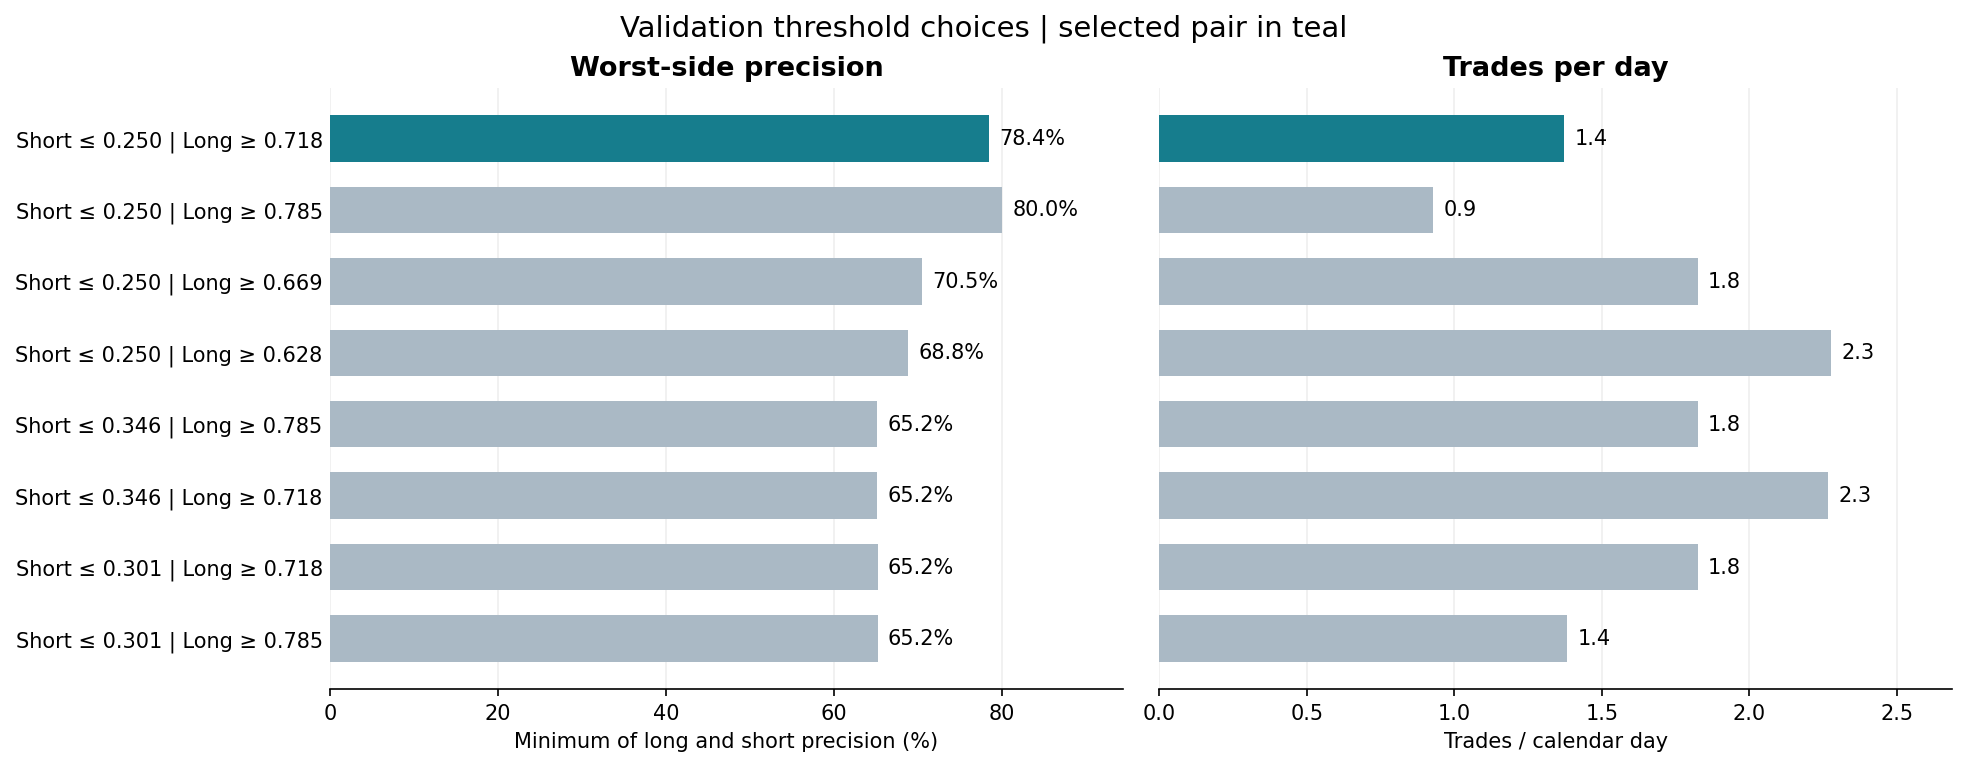

In [ ]:
# Choose one threshold pair on the reserved selection block, then save it unchanged.
MIN_TRADES_PER_DAY = 0.75
MAX_TRADES_PER_DAY = 3.00
MIN_SIDE_COUNT = 30
MIN_COVERAGE, TARGET_COVERAGE, MAX_COVERAGE = 0.10, 0.20, 0.30

val_prob = calibrate_probs(predict_prob_raw(X_select))
n_days = max(len(calendar_from_slices(selection_slices)), 1)
# Snap to observed scores, so empty numeric gaps do not repeat the same selections.
ranked_scores = np.sort(val_prob)
def score_boundaries(quantiles):
    positions = np.rint(np.asarray(quantiles) * (len(ranked_scores) - 1)).astype(int)
    return np.unique(ranked_scores[positions])
LOW_GRID = score_boundaries([0.025, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
HIGH_GRID = score_boundaries([0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.975])

def precision_lower_bound(correct, total):
    # A conservative ranking score that penalizes small selected samples.
    if total == 0:
        return 0.0
    z = 1.96
    p = correct / total
    return (p + z*z/(2*total) - z*np.sqrt(p*(1-p)/total + z*z/(4*total*total))) / (1 + z*z/total)

rows, seen = [], set()
for t_lo in LOW_GRID:
    for t_hi in HIGH_GRID:
        if t_lo >= t_hi:
            continue
        long_m, short_m = val_prob >= t_hi, val_prob <= t_lo
        signature = (np.packbits(long_m).tobytes(), np.packbits(short_m).tobytes())
        if signature in seen:
            continue
        seen.add(signature)
        n_long, n_short = int(long_m.sum()), int(short_m.sum())
        n_trade = n_long + n_short
        if not n_long or not n_short:
            continue
        correct_long = int(((y_select == 1) & long_m).sum())
        correct_short = int(((y_select == 0) & short_m).sum())
        long_p, short_p = correct_long / n_long, correct_short / n_short
        rows.append({'short_thr': float(t_lo), 'long_thr': float(t_hi),
                     'trades/day': n_trade / n_days, 'n_longs': n_long, 'n_shorts': n_short,
                     'long_prec': long_p, 'short_prec': short_p, 'min_prec': min(long_p, short_p),
                     'coverage_%': 100 * n_trade / len(y_select),
                     'selection_score': min(precision_lower_bound(correct_long, n_long),
                                            precision_lower_bound(correct_short, n_short))})
grid = pd.DataFrame(rows, columns=['short_thr', 'long_thr', 'trades/day', 'n_longs', 'n_shorts',
                                  'long_prec', 'short_prec', 'min_prec', 'coverage_%', 'selection_score'])
eligible = ((grid['trades/day'] >= MIN_TRADES_PER_DAY) & (grid['trades/day'] <= MAX_TRADES_PER_DAY)
            & (grid['n_longs'] >= MIN_SIDE_COUNT) & (grid['n_shorts'] >= MIN_SIDE_COUNT)
            & (grid['coverage_%'] >= 100 * MIN_COVERAGE) & (grid['coverage_%'] <= 100 * MAX_COVERAGE))
elig = grid.loc[eligible].copy()

THRESHOLD_POLICY_ENABLED = bool(len(elig))
if len(elig):
    elig['coverage_distance'] = (elig['coverage_%'] - 100 * TARGET_COVERAGE).abs()
    elig = elig.sort_values(['selection_score', 'coverage_distance'], ascending=[False, True])
    best = elig.iloc[0]
    LONG_THRESHOLD, SHORT_THRESHOLD = float(best['long_thr']), float(best['short_thr'])

else:
    # Disable trading if no pair meets the requirements.
    LONG_THRESHOLD, SHORT_THRESHOLD = 2.0, -1.0

threshold_policy = {'enabled': THRESHOLD_POLICY_ENABLED,
                    'long_threshold': LONG_THRESHOLD, 'short_threshold': SHORT_THRESHOLD,
                    'm1_threshold': threshold, 'm1_signal_gap': m1_settings['m1_signal_gap'],
                    'model_file': 'm2_tree_ensemble.npz', 'calibrator_file': 'm2_calibrator.pkl',
                    'calibrator': CALIBRATOR, 'feature_version': 'accuracy_update_v1',
                    'selection_rule': 'maximum_worst_side_wilson_lower_bound',
                    'raw_max_target_pct_long': M2_MAX_TARGET_PCT_LONG,
                    'raw_max_target_pct_short': M2_MAX_TARGET_PCT_SHORT,
                    'move_filter': 'skip_if_existing_raw_4ATR_over_close_exceeds_chosen_side_max',
                    'selection_start': calibration_end.isoformat(), 'selection_end': val_end.isoformat(),
                    'min_side_count': MIN_SIDE_COUNT, 'min_coverage': MIN_COVERAGE,
                    'target_coverage': TARGET_COVERAGE, 'max_coverage': MAX_COVERAGE}
with open('m2_thresholds.json', 'w') as f:
    json.dump(threshold_policy, f, indent=2)
print(f'Chosen thresholds: short <= {SHORT_THRESHOLD:.4f}, long >= {LONG_THRESHOLD:.4f}')

# Compare the eight highest-ranked eligible pairs.
choices = elig.head(8).iloc[::-1]
if len(choices):
    labels = [f'Short ≤ {row.short_thr:.3f} | Long ≥ {row.long_thr:.3f}'
              for row in choices.itertuples()]
    colors = ['#167d8d' if index == elig.index[0] else '#aab9c5' for index in choices.index]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, layout='constrained')
    positions = np.arange(len(choices))
    for ax, values, title, unit in [
        (axes[0], choices['min_prec'] * 100, 'Worst-side precision', '%'),
        (axes[1], choices['trades/day'], 'Trades per day', ''),
    ]:
        bars = ax.barh(positions, values, color=colors, height=0.65)
        ax.bar_label(bars, labels=[f'{value:.1f}{unit}' for value in values], padding=5, fontsize=10)
        ax.set_xlim(0, max(values.max() * 1.18, 1))
        ax.set_title(title, fontsize=13, weight='bold')
        ax.grid(axis='x', alpha=0.2)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.tick_params(axis='y', length=0)
    axes[0].set_yticks(positions, labels, fontsize=10)
    axes[0].set_xlabel('Minimum of long and short precision (%)')
    axes[1].set_xlabel('Trades / calendar day')
    fig.suptitle('Validation threshold choices | selected pair in teal', fontsize=14)
    plt.show()
else:
    print('No threshold pairs meet the sample and coverage requirements.')

### Confusion Matrix

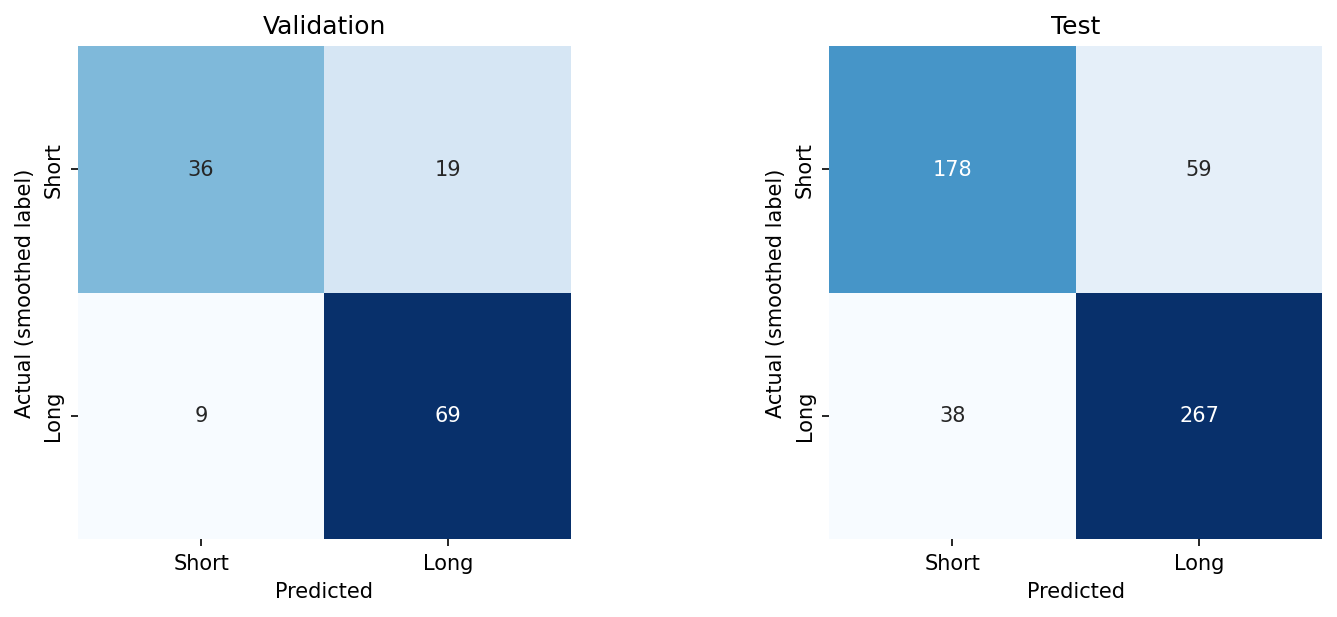

     Split  Trades  Long  Short  Accuracy %  Trades/day
Validation     133    88     45       78.95        1.37
      Test     542   326    216       82.10        1.35


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')
rows = []
for ax, name, X, y, slices in [
    (axes[0], 'Validation', X_select, y_select, selection_slices),
    (axes[1], 'Test', X_test, y_test, test_slices),
]:
    prob = calibrate_probs(predict_prob_raw(X))
    longs = prob >= LONG_THRESHOLD
    shorts = prob <= SHORT_THRESHOLD
    selected = longs | shorts
    predicted = longs[selected].astype(int)
    actual = y[selected]
    matrix = confusion_matrix(actual, predicted, labels=[0, 1])
    sns.heatmap(matrix, ax=ax, annot=True, fmt='d', cmap='Blues', cbar=False,
                square=True, xticklabels=['Short', 'Long'], yticklabels=['Short', 'Long'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    days = max(len(calendar_from_slices(slices)), 1)
    rows.append({
        'Split': name,
        'Trades': int(selected.sum()),
        'Long': int(longs.sum()),
        'Short': int(shorts.sum()),
        'Accuracy %': 100 * (actual == predicted).mean() if len(actual) else np.nan,
        'Trades/day': selected.sum() / days,
    })
plt.show()
print(pd.DataFrame(rows).round(2).to_string(index=False))

## Equity curve

Unfiltered signals versus side-specific distance caps. Trades use equal notional, allow overlapping positions, and assume fills at the barriers, with stop-loss priority on same-bar ties. Fees, slippage and funding are excluded.

Curves are ordered by entry; drawdown is the drop in cumulative return in percentage points. The caps were developed using data that includes this test period, so filtered results are development evidence.

       Policy  Trades  Win rate %  Return/trade %  Total return %  Drawdown (pp)
   Unfiltered     542      58.487           0.067          36.183        -13.123
Side-specific     474      60.338           0.100          47.397         -4.470


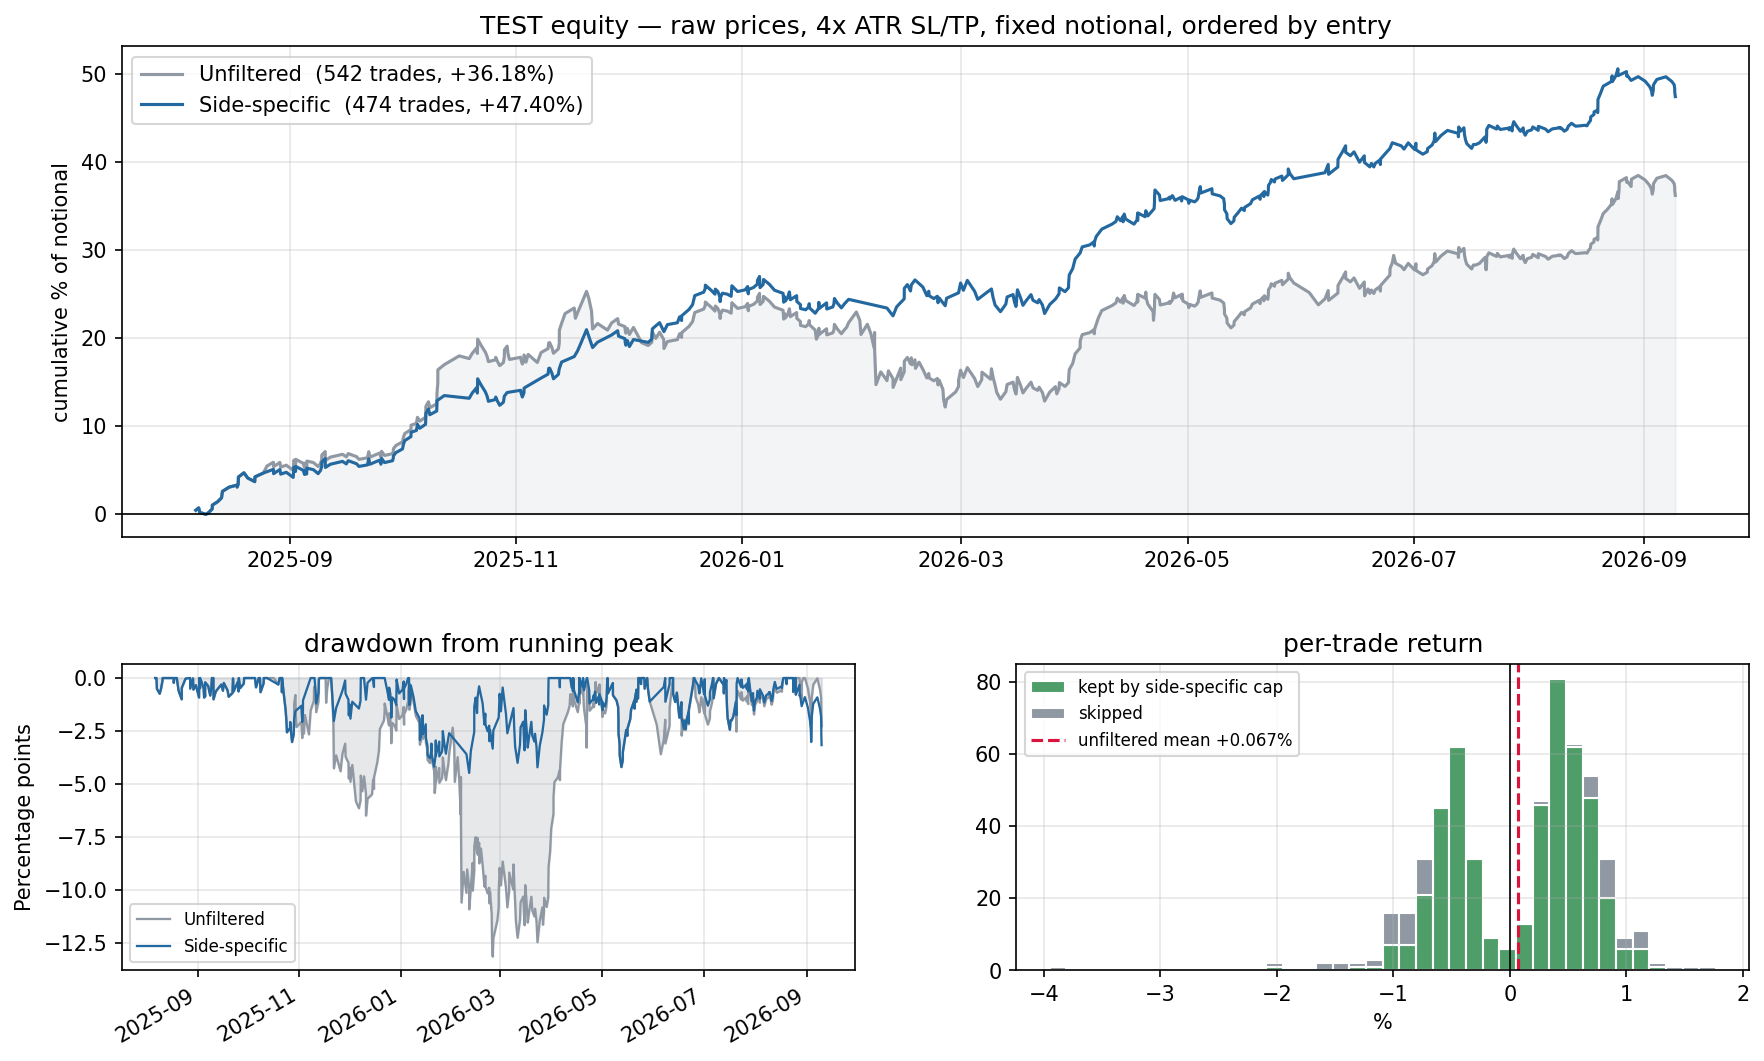

In [ ]:
BARRIER_MULT    = 4      # SL and TP, both at BARRIER_MULT x ATR_raw
TIME_LIMIT_BARS = 120    # matches label_triple_barrier(time_limit=...)

ts_test = pd.DatetimeIndex(ts_m2_test)
prob = calibrate_probs(predict_prob_raw(X_test))

long_m  = prob >= LONG_THRESHOLD
short_m = prob <= SHORT_THRESHOLD
trade_m = long_m | short_m

if trade_m.sum() == 0:
    print("No trades at these thresholds.")
else:
    traded_ts = ts_test[trade_m]
    side = long_m[trade_m].astype(int)          # 1 = long, 0 = short

    _df_u = df[~df.index.duplicated(keep='first')]
    h_raw = _df_u['high'].to_numpy(np.float64)
    l_raw = _df_u['low'].to_numpy(np.float64)
    c_raw = _df_u['close'].to_numpy(np.float64)
    a_raw = _df_u['ATR_raw'].to_numpy(np.float64)
    n_bars = len(_df_u)
    pos = _df_u.index.get_indexer(traded_ts)

    ret     = np.full(len(pos), np.nan)
    why     = np.empty(len(pos), dtype=object)
    held    = np.zeros(len(pos), dtype=int)
    band_pc = np.full(len(pos), np.nan)

    for k, (i, s) in enumerate(zip(pos, side)):
        if i < 0 or not np.isfinite(a_raw[i]) or a_raw[i] <= 0:
            continue
        entry = c_raw[i]
        band  = BARRIER_MULT * a_raw[i]
        tp = entry + band if s == 1 else entry - band
        sl = entry - band if s == 1 else entry + band
        band_pc[k] = band / entry

        end, out = min(i + 1 + TIME_LIMIT_BARS, n_bars), None
        for j in range(i + 1, end):
            if s == 1:
                hit_sl, hit_tp = l_raw[j] <= sl, h_raw[j] >= tp
            else:
                hit_sl, hit_tp = h_raw[j] >= sl, l_raw[j] <= tp
            # both inside one bar: the intrabar path is unknown, so take the stop.
            # (label_triple_barrier resolves that tie the other way for shorts,
            #  which is why a few simulated outcomes disagree with target_raw.)
            if hit_sl:
                out = (sl, 'sl', j - i); break
            if hit_tp:
                out = (tp, 'tp', j - i); break
        if out is None:
            out = (c_raw[end - 1], 'time', end - 1 - i)   # marked out at the limit

        px, reason, bars = out
        ret[k]  = (px - entry) / entry if s == 1 else (entry - px) / entry
        why[k]  = reason
        held[k] = bars

    ok = np.isfinite(ret)
    # The cap is evaluated on band_pc, which was recorded at the entry candle.
    # A signal with no usable ATR fails any cap that is actually set.
    def passes_distance(cap):
        if cap is None:
            return np.ones(len(band_pc), dtype=bool)
        if not (np.isfinite(cap) and cap > 0):
            raise ValueError('Distance caps must be positive fractions or None.')
        return np.isfinite(band_pc) & (band_pc > 0) & (band_pc <= cap)

    POLICIES = [('Unfiltered',          None,                        None,                        '#9099a3'),
                ('Side-specific',       M2_MAX_TARGET_PCT_LONG,      M2_MAX_TARGET_PCT_SHORT,     '#2468a0')]

    policy_masks = {}
    for name, cap_long, cap_short, _color in POLICIES:
        policy_masks[name] = np.where(side == 1, passes_distance(cap_long),
                                                 passes_distance(cap_short))

    def policy_result(name, mask):
        """Summarize trades retained by a distance policy."""
        sel = ok & mask
        r_ = ret[sel]
        ts_ = traded_ts[sel]
        order = np.argsort(ts_.values)
        eq_ = np.cumsum(r_[order])
        dd_ = eq_ - np.maximum.accumulate(eq_) if len(eq_) else eq_
        wins_, losses_ = r_[r_ > 0], r_[r_ < 0]
        n_ = len(r_)
        days_ = pd.Series(ts_).dt.normalize().nunique() if n_ else 0
        sd_ = r_.std(ddof=1) if n_ > 1 else np.nan
        return {'name': name, 'mask': sel, 'r': r_, 'ts': ts_[order], 'eq': eq_, 'dd': dd_,
                'n': n_, 'n_long': int((side[sel] == 1).sum()), 'n_short': int((side[sel] == 0).sum()),
                'coverage_pct': 100 * n_ / max(int(ok.sum()), 1),
                'band_pct_mean': 100 * np.nanmean(band_pc[sel]) if n_ else np.nan,
                'hit_rate_pct': 100 * (r_ > 0).mean() if n_ else np.nan,
                'avg_win_pct': 100 * wins_.mean() if len(wins_) else np.nan,
                'avg_loss_pct': 100 * losses_.mean() if len(losses_) else np.nan,
                'profit_factor': wins_.sum() / abs(losses_.sum()) if len(losses_) and losses_.sum() else np.nan,
                'mean_return_pct': 100 * r_.mean() if n_ else np.nan,
                'median_return_pct': 100 * np.median(r_) if n_ else np.nan,
                'sd_return_pct': 100 * sd_ if n_ > 1 else np.nan,
                'total_return_pct': 100 * r_.sum() if n_ else np.nan,
                'per_traded_day_pct': 100 * r_.sum() / days_ if days_ else np.nan,
                'max_drawdown_pct': 100 * dd_.min() if n_ else np.nan,
                't_stat': r_.mean() / (sd_ / np.sqrt(n_)) if n_ > 1 and sd_ > 0 else 0.0,
                'traded_days': days_,
                'exits': {k: int((why[sel] == k).sum()) for k in ['tp', 'sl', 'time']},
                'mean_held': held[sel].mean() if n_ else np.nan,
                'median_held': np.median(held[sel]) if n_ else np.nan}

    results = [policy_result(name, policy_masks[name]) for name, *_ in POLICIES]
    by_name = {res['name']: res for res in results}

    filter_summary = pd.DataFrame([{
        'Policy': res['name'],
        'Trades': res['n'],
        'Win rate %': res['hit_rate_pct'],
        'Return/trade %': res['mean_return_pct'],
        'Total return %': res['total_return_pct'],
        'Drawdown (pp)': res['max_drawdown_pct'],
    } for res in results])
    print(filter_summary.round(3).to_string(index=False))

    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.32, wspace=0.22)

    ax = fig.add_subplot(gs[0, :])
    for (name, _cl, _cs, color) in POLICIES:
        res = by_name[name]
        if not res['n']:
            continue
        ax.plot(res['ts'].values, 100 * res['eq'], lw=1.5, color=color,
                label=f"{name}  ({res['n']} trades, {res['total_return_pct']:+.2f}%)")
    base = by_name['Unfiltered']
    if base['n']:
        ax.fill_between(base['ts'].values, 100 * base['eq'], 0, alpha=0.10, color='#9099a3')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'TEST equity — raw prices, {BARRIER_MULT}x ATR SL/TP, '
                 f'fixed notional, ordered by entry')
    ax.set_ylabel('cumulative % of notional')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, 0])
    for (name, _cl, _cs, color) in POLICIES:
        res = by_name[name]
        if not res['n']:
            continue
        ax.plot(res['ts'].values, 100 * res['dd'], lw=1.1, color=color, label=name)
    ax.fill_between(base['ts'].values, 100 * base['dd'], 0, color='#9099a3', alpha=0.22)
    ax.set_title('drawdown from running peak')
    ax.set_ylabel('Percentage points')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    ax = fig.add_subplot(gs[1, 1])
    _side_specific = policy_masks['Side-specific']
    bins = np.histogram_bin_edges(100 * ret[ok], bins=40)
    ax.hist([100 * ret[ok & _side_specific], 100 * ret[ok & ~_side_specific]],
            bins=bins, stacked=True, color=['#4f9d69', '#9099a3'], edgecolor='white',
            label=['kept by side-specific cap', 'skipped'])
    ax.axvline(0, color='black', lw=0.8)
    ax.axvline(100 * base['r'].mean(), color='crimson', ls='--',
               label=f"unfiltered mean {100*base['r'].mean():+.3f}%")
    ax.set_title('per-trade return')
    ax.set_xlabel('%')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.show()